<a href="https://colab.research.google.com/github/zzzJuanzzz/extensionistaUNINTER/blob/main/Ocorr%C3%AAncia_de_Les%C3%B5es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IMPORTAÇÃO E LEITURA DA PLANILHA DE LESÕES**

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib.patches as mpatches
from google.colab import files
warnings.filterwarnings('ignore')

df = pd.read_excel('/content/Ocorrências de Lesões em esporte de combate (respostas) (1).xlsx')
df.head()

,Carimbo de data/hora,Seu nome,Idade,Gênero,Qual modalidade pratica ?,Quantas dias você treina por semana?,"Além da luta, você pratica outro esporte ?","Se respondeu ""Sim"" na última pergunta, qual outro esporte você pratica ?",Você já sofreu alguma lesão nos últimos 12 meses?,"Se já sofreu lesões, em qual parte do corpo sofreu essa lesão ?",...,Você tem uma alimentação equilibrada ?,Você fuma ou bebe álcool com frequência ?,Qual sua principal motivação para treinar ?,O que mais dificulta você a treinar ?,Você já pensou em parar de treinar por causa de lesões ?,Você já teve mais de uma lesão no mesmo local ?,Você fez fisioterapia para recupeação da sua lesaõ ?,Quantos treinos de Sparring você faz no mês ?,Pontuação,Coluna 7
0,2025-11-20 09:12:37.313,Luis Felipe,18 - 25,Masculino,"Muay Thai, Jiu Jitsu",3 a 4 dias,Sim,Corrida,Sim,"Pé / Tornozelo, Ombro",...,"Parcialmente, me alimento bem 80% do tempo",Não bebo,Gosto de competir mas é por lazer.,Falta de tempo,Não,Não,Não,5 a 6 treinos,0.0,NaN
1,2025-11-20 09:13:05.745,Juan Pablo,18 - 25,Masculino,"Boxe, Muay Thai",5 dias ou +,Sim,Corrida,Sim,Joelho,...,"Parcialmente, me alimento bem 80% do tempo","Sim, ocasionalmente (em festas ou comemorações)",Saúde,Falta de tempo,Sim,Sim,Não,3 a 4 treinos (1 por semana),0.0,NaN
2,2025-11-20 09:17:44.450,João Batista,26 - 35,Masculino,Muay Thai,3 a 4 dias,Sim,Futebol,Sim,"Pé / Tornozelo, Ombro",...,"Não, como o que der vontade, treino pra isso","Sim, frequentemente ( todos finais de semana o...",Competição,Falta de tempo,Não,Não,Não,1 a 2 treinos,0.0,NaN
3,2025-11-20 09:34:19.338,Pedro Goularte,18 - 25,Masculino,Jiu Jitsu,3 a 4 dias,Sim,Corrida,Sim,NaN,...,"Parcialmente, me alimento bem 80% do tempo",Não bebo,Desempenho,Falta de tempo,Não,Não,Não,+6 treinos de Sparring,0.0,NaN
4,2025-11-20 09:35:46.523,Fábio,26 - 35,Masculino,Jiu Jitsu,3 a 4 dias,Sim,Natação,Sim,"Joelho, Ombro, Costela, Cotovelo / Braço",...,"Parcialmente, me alimento bem 80% do tempo","Sim, ocasionalmente (em festas ou comemorações)",Saúde,Lesões,Não,Sim,Sim,Não faço,0.0,NaN


 **CRIAÇÃO DE UMA CÓPIA DA PLANILHA ORIGINAL E TRATAMENTO DOS DADOS**

In [ ]:
df_copia = df.copy()

df_copia.columns


Index(['Carimbo de data/hora', 'Seu nome', 'Idade', 'Gênero',
       'Qual modalidade pratica ?', 'Quantas dias você treina por semana?',
       'Além da luta, você pratica outro esporte ?',
       'Se respondeu "Sim" na última pergunta, qual outro esporte você pratica ?',
       'Você já sofreu alguma lesão nos últimos 12 meses?',
       'Se já sofreu lesões, em qual parte do corpo sofreu essa lesão ?',
       'Você faz alongamento e aquecimento antes do treino ? ',
       'Você prática fortalecimento/musculação como prevenções de lesões ?',
       'Quanto tempo demorou para se recuperar ?',
       'Você voltou a treinar antes de se recuperar 100%?',
       'Há quanto tempo você pratica esse esporte ?',
       'Com qual frequência você sente dores após o treino ?',
       'Quantas horas você dorme em média por noite ?',
       'Você tem uma alimentação equilibrada ?',
       'Você fuma ou bebe álcool com frequência ?',
       'Qual sua principal motivação para treinar ?',
       'O qu

In [ ]:
df_copia = df.copy()

df_copia = df_copia.drop(["Carimbo de data/hora", "Seu nome", "Pontuação", "Coluna 7"], axis= 1 )

df_copia.columns


cols_categoria = [
    'Idade',
    'Gênero',
    'Qual modalidade pratica ?',
    'Quantas dias você treina por semana?',
    'Além da luta, você pratica outro esporte ?',
    'Se respondeu "Sim" na última pergunta, qual outro esporte você pratica ?',
    'Você já sofreu alguma lesão nos últimos 12 meses?',
    'Se já sofreu lesões, em qual parte do corpo sofreu essa lesão ?',
    'Você faz alongamento e aquecimento antes do treino ? ',
    'Você prática fortalecimento/musculação como prevenções de lesões ?',
    'Quanto tempo demorou para se recuperar ?',
    'Você voltou a treinar antes de se recuperar 100%?',
    'Há quanto tempo você pratica esse esporte ?',
    'Com qual frequência você sente dores após o treino ?',
    'Quantas horas você dorme em média por noite ?',
    'Você tem uma alimentação equilibrada ?',
    'Você fuma ou bebe álcool com frequência ?',
    'Qual sua principal motivação para treinar ?',
    'O que mais dificulta você a treinar ?',
    'Você já pensou em parar de treinar por causa de lesões ?',
    'Você já teve mais de uma lesão no mesmo local ?',
    'Você fez fisioterapia para recupeação da sua lesaõ ?',
    'Quantos treinos de Sparring você faz no mês ?'
]

df_copia[cols_categoria] = df_copia[cols_categoria].astype('category')

for col in df_copia.select_dtypes(include='category'):
    print(f'\n{col}')
    print(df_copia[col].value_counts())




Idade
Idade
18 - 25        33
26 - 35        18
35 - 45         8
Menos de 18     6
Name: count, dtype: int64

Gênero
Gênero
Masculino                56
Feminino                  8
Prefiro não responder     1
Name: count, dtype: int64

Qual modalidade pratica ?
Qual modalidade pratica ?
Jiu Jitsu                                          22
Muay Thai                                          17
Boxe, Muay Thai, Jiu Jitsu                          9
Boxe, Muay Thai                                     6
Boxe                                                4
Muay Thai, Jiu Jitsu                                4
Boxe, Muay Thai, Jiu Jitsu, Kikbox                  1
Boxe, Muay Thai, Jiu Jitsu, Musculação, corrida     1
Krav Maga                                           1
Name: count, dtype: int64

Quantas dias você treina por semana?
Quantas dias você treina por semana?
3 a 4 dias     28
5 dias ou +    19
0 a 2 dias     18
Name: count, dtype: int64

Além da luta, você pratica outro esporte ?


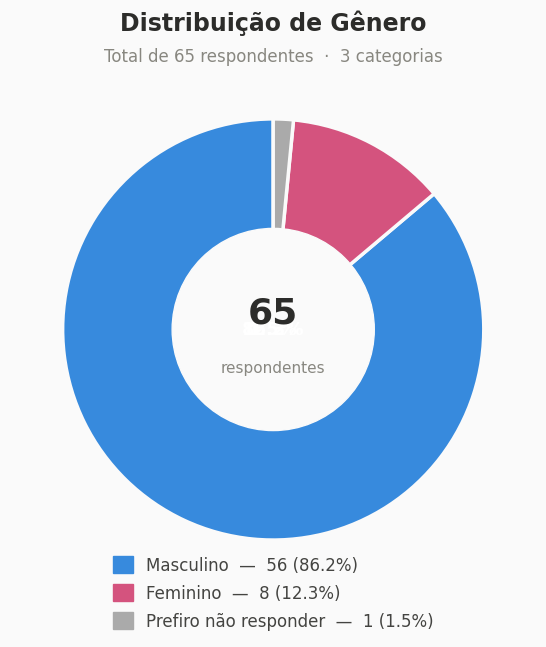

In [ ]:
contagem = df_copia["Gênero"].value_counts()

percentual = (
    df_copia["Gênero"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

tabela_genero = pd.DataFrame({
    "Quantidade": contagem,
    "Percentual": percentual
})

cores = {
    "Masculino":            "#378ADD",   # azul
    "Feminino":             "#D4537E",   # rosa
    "Prefiro não informar": "#888780",   # cinza
}

bar_colors = [cores.get(g, "#AAAAAA") for g in tabela_genero.index]

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

wedges, texts, autotexts = ax.pie(
    tabela_genero["Quantidade"],
    labels=None,
    colors=bar_colors,
    autopct="%1.1f%%",
    pctdistance=0,
    startangle=90,
    wedgeprops={"linewidth": 2.5,
                "edgecolor": "#FAFAFA",
                "antialiased": True},
)

for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_fontweight("bold")
    autotext.set_color("white")

centro = plt.Circle((0, 0), 0.48, color="#FAFAFA")
ax.add_patch(centro)

total = int(tabela_genero["Quantidade"].sum())
ax.text(0, 0.08, str(total),
        ha="center", va="center",
        fontsize=26, fontweight="bold", color="#2C2C2A")
ax.text(0, -0.18, "respondentes",
        ha="center", va="center",
        fontsize=11, color="#888780")

handles = [
    mpatches.Patch(
        color=cores.get(label, "#AAAAAA"),
        label=f"{label}  —  {int(tabela_genero.loc[label, 'Quantidade'])} ({tabela_genero.loc[label, 'Percentual']:.1f}%)"
    )
    for label in tabela_genero.index
]
ax.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=1,
    frameon=False,
    fontsize=12,
    handlelength=1.2,
    handleheight=1.2,
    labelcolor="#444441",
    labelspacing=0.6,
)

fig.text(0.5, 0.97,
         "Distribuição de Gênero",
         ha="center", fontsize=17, fontweight="bold", color="#2C2C2A", va="top")
fig.text(0.5, 0.915,
         f"Total de {total} respondentes  ·  {len(tabela_genero)} categorias",
         ha="center", fontsize=12, color="#888780", va="top")

plt.tight_layout(rect=[0, 0.05, 1, 0.91])
plt.savefig("grafico_generos.png", dpi=150, bbox_inches="tight")
plt.show()
#files.download("grafico_generos.png")

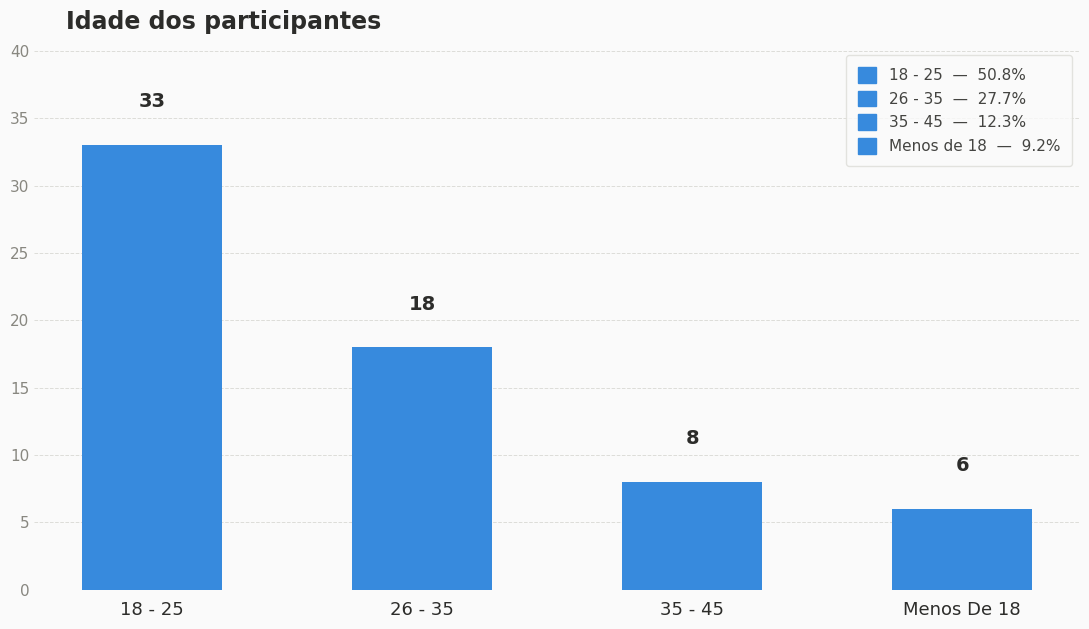

In [ ]:
contagem_idades = df_copia["Idade"].value_counts()

percentual = (
    df_copia["Idade"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

tabela_idades = pd.DataFrame({
    "Quantidade": contagem_idades,
    "Percentual": percentual
})



fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")


x = np.arange(len(tabela_idades))

barras = ax.bar(
    x,
    tabela_idades["Quantidade"],
    color="#378ADD",
    width=0.52,
    zorder=3,
    linewidth=0,
)

for barra, (idx, row) in zip(barras, tabela_idades.iterrows()):
    h = barra.get_height()
    cx = barra.get_x() + barra.get_width() / 2

    ax.text(cx, h + 2.5, str(int(row["Quantidade"])),
            ha="center", va="bottom",
            fontsize=14, fontweight="bold", color="#2C2C2A")



ax.yaxis.grid(True, color="#DDDDD8", linewidth=0.7, linestyle="--", zorder=0)
ax.set_axisbelow(True)

ax.set_xticks(x)
ax.set_xticklabels(
    [i.title() for i in tabela_idades.index],
    fontsize=13, fontweight="500", color="#2C2C2A"
)

ax.tick_params(axis="x", length=0, pad=8)
ax.tick_params(axis="y", labelsize=11, colors="#888780", length=0)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

fig.text(0.065, 0.96,
         "Idade dos participantes",
         fontsize=17, fontweight="bold", color="#2C2C2A", va="top")

handles = [
    mpatches.Patch(
        color="#378ADD",
        label=f"{idx}  —  {row['Percentual']:.1f}%"
    )
    for idx, row in tabela_idades.iterrows()
]

ax.legend(
    handles=handles,
    loc="upper right",
    frameon=True,
    facecolor="#FAFAFA",
    edgecolor="#DDDDD8",
    fontsize=11,
    handlelength=1.2,
    handleheight=1.2,
    labelcolor="#444441",
    labelspacing=0.5,
    borderpad=0.8,
)

ax.set_ylim(0, tabela_idades["Quantidade"].max() * 1.22)

ax.set_ylabel("")
ax.set_xlabel("")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("grafico_idades.png", dpi=150, bbox_inches="tight")
plt.show()
#files.download("grafico_idades.png")


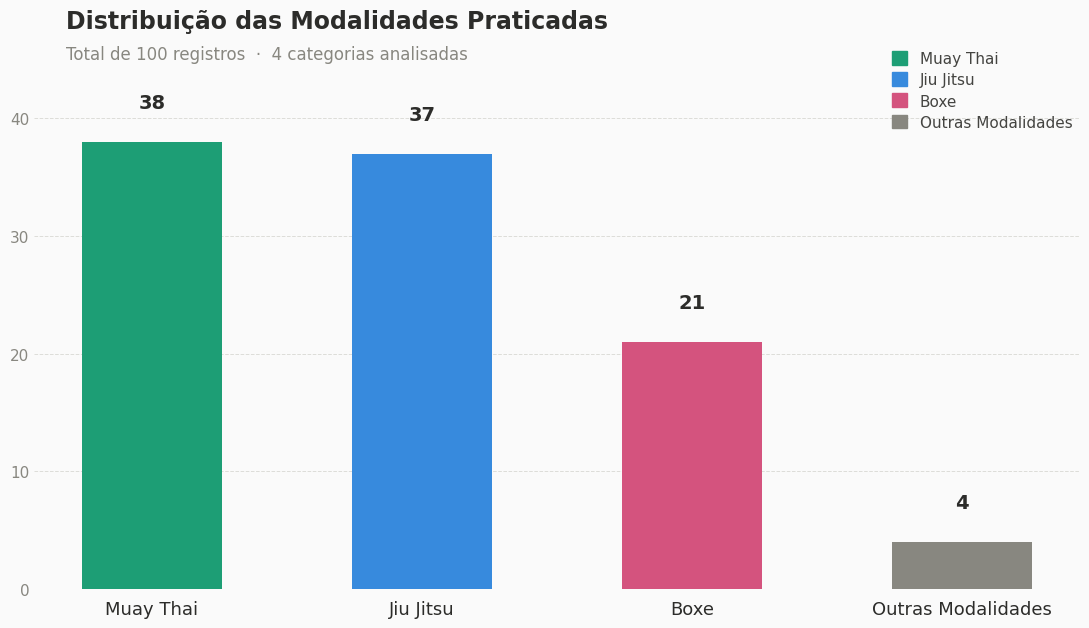

In [ ]:
principais = ["MUAY THAI", "JIU JITSU", "BOXE"]

modalidades = (
    df_copia["Qual modalidade pratica ?"]
    .str.upper()
    .str.split(", ")
    .explode()
)


modalidades_agrupadas = modalidades.where(
    modalidades.isin(principais),
    "OUTRAS MODALIDADES"
)

frequencia = modalidades_agrupadas.value_counts()

percentual = (
    modalidades_agrupadas.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

tabela_modalidades = pd.DataFrame({
    "Frequência": frequencia,
    "Percentual (%)": percentual
})

cores = {
    "MUAY THAI":          "#1D9E75",   # verde
    "JIU JITSU":          "#378ADD",   # azul
    "BOXE":               "#D4537E",   # rosa
    "OUTRAS MODALIDADES": "#888780",   # cinza
}

bar_colors = [cores[m] for m in tabela_modalidades.index]

fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

x = np.arange(len(tabela_modalidades))

barras = ax.bar(
    x,
    tabela_modalidades["Frequência"],
    color=bar_colors,
    width=0.52,
    zorder=3,
    linewidth=0,
)

for barra, (idx, row) in zip(barras, tabela_modalidades.iterrows()):
    h = barra.get_height()
    cx = barra.get_x() + barra.get_width() / 2

    ax.text(cx, h + 2.5, str(int(row["Frequência"])),
            ha="center", va="bottom",
            fontsize=14, fontweight="bold", color="#2C2C2A")


ax.yaxis.grid(True, color="#DDDDD8", linewidth=0.7, linestyle="--", zorder=0)
ax.set_axisbelow(True)

ax.set_xticks(x)
ax.set_xticklabels(
    [m.title() for m in tabela_modalidades.index],
    fontsize=13, fontweight="500", color="#2C2C2A"
)

ax.tick_params(axis="x", length=0, pad=8)
ax.tick_params(axis="y", labelsize=11, colors="#888780", length=0)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

fig.text(0.065, 0.96,
         "Distribuição das Modalidades Praticadas",
         fontsize=17, fontweight="bold", color="#2C2C2A", va="top")

fig.text(0.065, 0.905,
         f"Total de {int(frequencia.sum())} registros  ·  4 categorias analisadas",
         fontsize=12, color="#888780", va="top")

handles = [
    mpatches.Patch(color=cor, label=label.title())
    for label, cor in cores.items()
]
ax.legend(handles=handles, loc="upper right",
          frameon=False, fontsize=11,
          handlelength=1, handleheight=1,
          labelcolor="#444441", borderpad=0, labelspacing=0.4)

ax.set_ylim(0, tabela_modalidades["Frequência"].max() * 1.22)

ax.set_ylabel("")
ax.set_xlabel("")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("grafico_distribuicaoModalidades.png", dpi=150, bbox_inches="tight")
plt.show()
#files.download("grafico_distribuicaoModalidades.png")

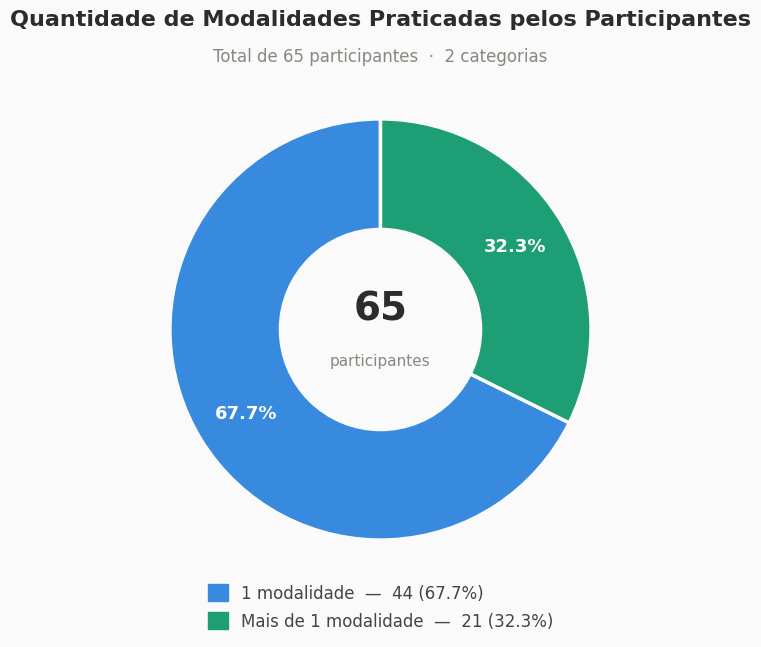

In [ ]:
import matplotlib.patches as mpatches

n = len(df_copia)

qtd_mais_de_uma = (
    (df_copia["Qual modalidade pratica ?"]
     .str.count(",") + 1 > 1)
    .sum()
)

uma_modalidade = (
    (df_copia["Qual modalidade pratica ?"]
     .str.count(",") + 1 == 1)
    .sum()
)

percentual = qtd_mais_de_uma / n * 100

labels = ["1 modalidade", "Mais de 1 modalidade"]
valores = [uma_modalidade, qtd_mais_de_uma]

cores = ["#378ADD", "#1D9E75"]

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

wedges, texts, autotexts = ax.pie(
    valores,
    labels=None,
    colors=cores,
    autopct="%1.1f%%",
    pctdistance=0.75,
    startangle=90,
    wedgeprops={"linewidth": 2.5,
                "edgecolor": "#FAFAFA",
                "antialiased": True},
)

for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_fontweight("bold")
    autotext.set_color("white")

centro = plt.Circle((0, 0), 0.48, color="#FAFAFA")
ax.add_patch(centro)

ax.text(0, 0.10, str(n),
        ha="center", va="center",
        fontsize=28, fontweight="bold", color="#2C2C2A")
ax.text(0, -0.15, "participantes",
        ha="center", va="center",
        fontsize=11, color="#888780")

handles = [
    mpatches.Patch(
        color=cor,
        label=f"{label}  —  {valor} ({valor/n*100:.1f}%)"
    )
    for label, valor, cor in zip(labels, valores, cores)
]
ax.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=1,
    frameon=False,
    fontsize=12,
    handlelength=1.2,
    handleheight=1.2,
    labelcolor="#444441",
    labelspacing=0.6,
)

fig.text(0.5, 0.97,
         "Quantidade de Modalidades Praticadas pelos Participantes",
         ha="center", fontsize=16, fontweight="bold", color="#2C2C2A", va="top")
fig.text(0.5, 0.915,
         f"Total de {n} participantes  ·  2 categorias",
         ha="center", fontsize=12, color="#888780", va="top")

plt.tight_layout(rect=[0, 0.05, 1, 0.91])
plt.savefig("grafico_qtdModalidades.png", dpi=150, bbox_inches="tight")
plt.show()
#files.download("grafico_qtdModalidades.png")

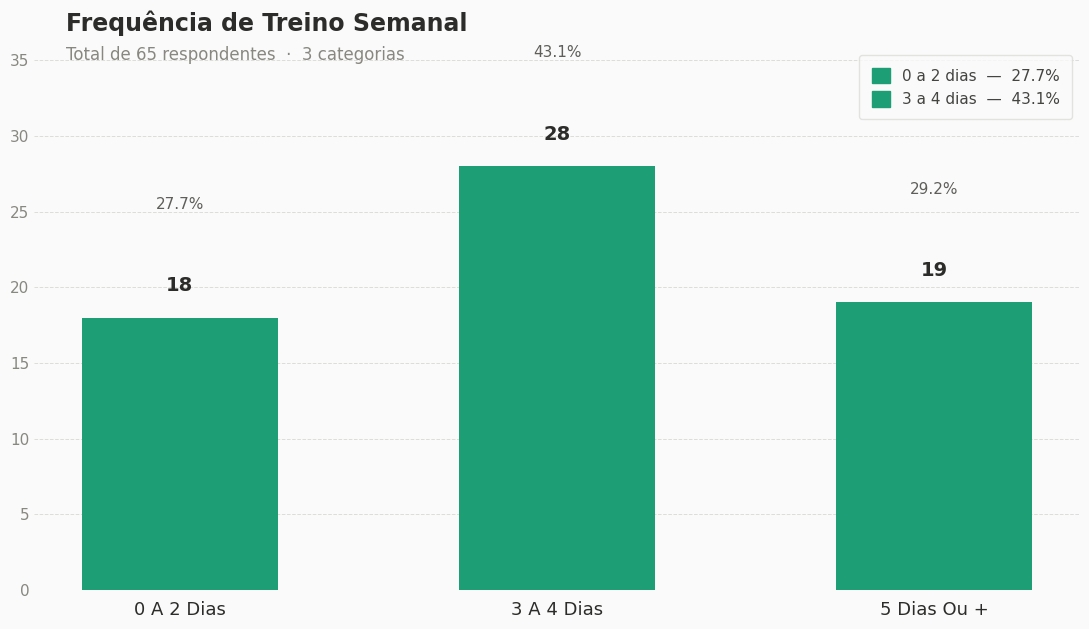

In [ ]:
frequencia_de_treino = df_copia["Quantas dias você treina por semana?"].value_counts()

percentual = (
    df_copia["Quantas dias você treina por semana?"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

tabela_frequencia_treino = pd.DataFrame({
    "Frequência": frequencia_de_treino,
    "Percentual (%)": percentual
})

tabela_frequencia_treino = tabela_frequencia_treino.sort_index()


fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

x = np.arange(len(tabela_frequencia_treino))

barras = ax.bar(
    x,
    tabela_frequencia_treino["Frequência"],
    color="#1D9E75",
    width=0.52,
    zorder=3,
    linewidth=0,
)

for barra, (idx, row) in zip(barras, tabela_frequencia_treino.iterrows()):
    h  = barra.get_height()
    cx = barra.get_x() + barra.get_width() / 2

    ax.text(cx, h + 1.5, str(int(row["Frequência"])),
            ha="center", va="bottom",
            fontsize=14, fontweight="bold", color="#2C2C2A")

    ax.text(cx, h + 7, f"{row['Percentual (%)']:.1f}%",
            ha="center", va="bottom",
            fontsize=11, color="#5F5E5A")

ax.yaxis.grid(True, color="#DDDDD8", linewidth=0.7, linestyle="--", zorder=0)
ax.set_axisbelow(True)

ax.set_xticks(x)
ax.set_xticklabels(
    [i.title() for i in tabela_frequencia_treino.index],
    fontsize=13, fontweight="500", color="#2C2C2A"
)

ax.tick_params(axis="x", length=0, pad=8)
ax.tick_params(axis="y", labelsize=11, colors="#888780", length=0)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

fig.text(0.065, 0.96,
         "Frequência de Treino Semanal",
         fontsize=17, fontweight="bold", color="#2C2C2A", va="top")
fig.text(0.065, 0.905,
         f"Total de {int(tabela_frequencia_treino['Frequência'].sum())} respondentes  ·  {len(tabela_frequencia_treino)} categorias",
         fontsize=12, color="#888780", va="top")

handles = [
    mpatches.Patch(color="#1D9E75", label=f"{idx}  —  {row['Percentual (%)']:.1f}%")
    for (idx, row), cor in zip(tabela_frequencia_treino.iterrows(), cores)
]
ax.legend(
    handles=handles,
    loc="upper right",
    frameon=True,
    facecolor="#FAFAFA",
    edgecolor="#DDDDD8",
    fontsize=11,
    handlelength=1.2,
    handleheight=1.2,
    labelcolor="#444441",
    labelspacing=0.5,
    borderpad=0.8,
)

ax.set_ylim(0, tabela_frequencia_treino["Frequência"].max() * 1.28)

ax.set_ylabel("")
ax.set_xlabel("")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("grafico_frequencia_de_Treino.png", dpi=150, bbox_inches="tight")
plt.show()
#files.download("grafico_frequencia_de_Treino.png")


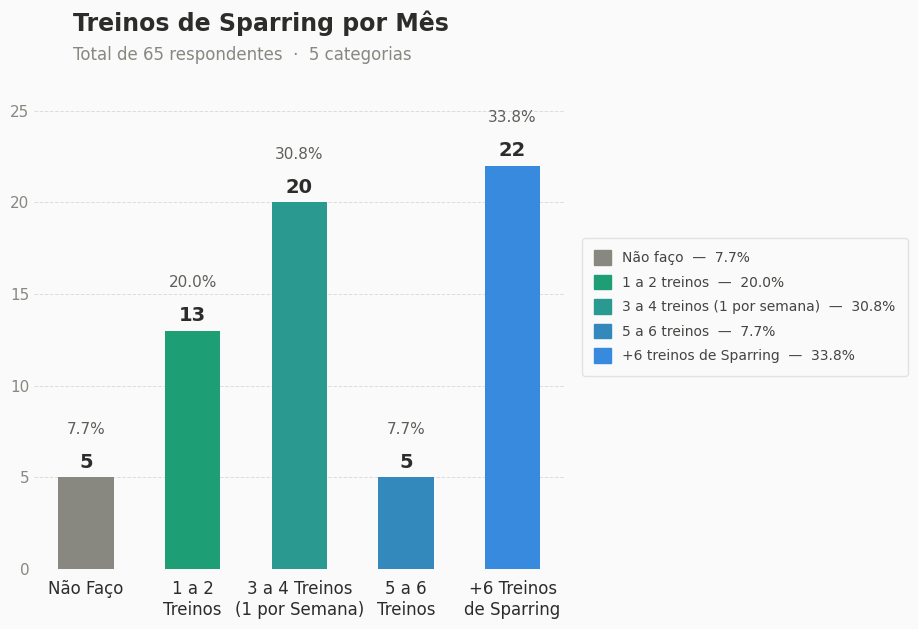

In [ ]:
qtd_sparring = df_copia['Quantos treinos de Sparring você faz no mês ?'].value_counts()

percentual_qtd_sparrging = (
    df_copia['Quantos treinos de Sparring você faz no mês ?']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

tabela_qtd_sparring = pd.DataFrame({
    "Quantidade": qtd_sparring,
    "Percentual": percentual_qtd_sparrging
})

ordem = [
    "Não faço",
    "1 a 2 treinos",
    "3 a 4 treinos (1 por semana)",
    "5 a 6 treinos",
    "+6 treinos de Sparring",
]
tabela_qtd_sparring = tabela_qtd_sparring.reindex(ordem)

cores_map = {
    "Não faço":                    "#888780",   # cinza  — não pratica
    "1 a 2 treinos":               "#1D9E75",   # verde
    "3 a 4 treinos (1 por semana)":"#2A9A90",   # verde-azulado
    "5 a 6 treinos":               "#3389BB",   # azul médio
    "+6 treinos de Sparring":      "#378ADD",   # azul  — maior volume
}
bar_colors = [cores_map.get(label, "#888780") for label in tabela_qtd_sparring.index]

fig, ax = plt.subplots(figsize=(12, 6.5))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

x = np.arange(len(tabela_qtd_sparring))

barras = ax.bar(
    x,
    tabela_qtd_sparring["Quantidade"],
    color=bar_colors,
    width=0.52,
    zorder=3,
    linewidth=0,
)

for barra, (idx, row) in zip(barras, tabela_qtd_sparring.iterrows()):
    h  = barra.get_height()
    cx = barra.get_x() + barra.get_width() / 2

    ax.text(cx, h + 0.3, str(int(row["Quantidade"])),
            ha="center", va="bottom",
            fontsize=14, fontweight="bold", color="#2C2C2A")

    ax.text(cx, h + 2.2, f"{row['Percentual']:.1f}%",
            ha="center", va="bottom",
            fontsize=11, color="#5F5E5A")

ax.yaxis.grid(True, color="#DDDDD8", linewidth=0.7, linestyle="--", zorder=0)
ax.set_axisbelow(True)

rotulos = [
    "Não Faço",
    "1 a 2\nTreinos",
    "3 a 4 Treinos\n(1 por Semana)",
    "5 a 6\nTreinos",
    "+6 Treinos\nde Sparring",
]
ax.set_xticks(x)
ax.set_xticklabels(rotulos, fontsize=12, fontweight="500", color="#2C2C2A")

ax.tick_params(axis="x", length=0, pad=8)
ax.tick_params(axis="y", labelsize=11, colors="#888780", length=0)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

fig.text(0.065, 0.96,
         "Treinos de Sparring por Mês",
         fontsize=17, fontweight="bold", color="#2C2C2A", va="top")
fig.text(0.065, 0.905,
         f"Total de {int(tabela_qtd_sparring['Quantidade'].sum())} respondentes  ·  5 categorias",
         fontsize=12, color="#888780", va="top")

handles = [
    mpatches.Patch(color=cor, label=f"{idx}  —  {row['Percentual']:.1f}%")
    for (idx, row), cor in zip(tabela_qtd_sparring.iterrows(), bar_colors)
]
ax.legend(
    handles=handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    facecolor="#FAFAFA",
    edgecolor="#DDDDD8",
    fontsize=10,
    handlelength=1.2,
    handleheight=1.2,
    labelcolor="#444441",
    labelspacing=0.7,
    borderpad=0.9,
)

ax.set_ylim(0, tabela_qtd_sparring["Quantidade"].max() * 1.30)
ax.set_ylabel("")
ax.set_xlabel("")

plt.tight_layout(rect=[0, 0, 0.78, 0.93])
plt.savefig("grafico_sparring.png", dpi=150, bbox_inches="tight")
plt.show()
#files.download("grafico_sparring.png")

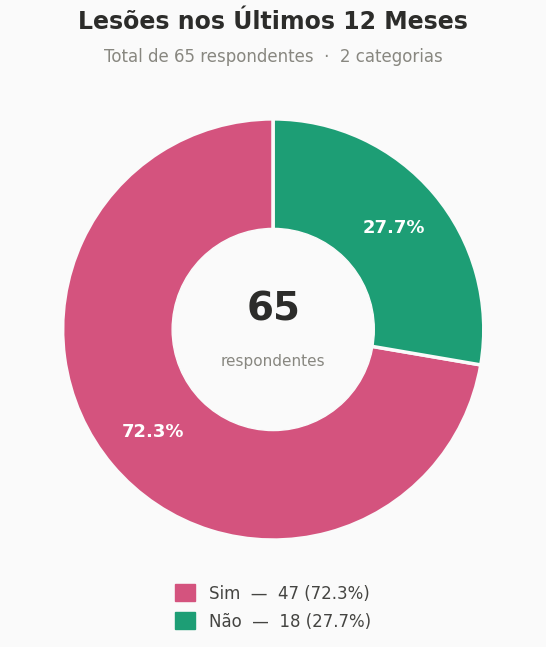

In [ ]:
lesionados = df_copia["Você já sofreu alguma lesão nos últimos 12 meses?"].value_counts()

percentual_lesionados = (
    df_copia["Você já sofreu alguma lesão nos últimos 12 meses?"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

tabela_lesionados = pd.DataFrame({
    "Quantidade": lesionados,
    "Percentual": percentual_lesionados
})

cores_map = {
    "Sim": "#D4537E",   # rosa — indica ocorrência de lesão
    "Não": "#1D9E75",   # verde — sem lesão
}
cores = [cores_map.get(label, "#888780") for label in tabela_lesionados.index]

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")


wedges, texts, autotexts = ax.pie(
    tabela_lesionados["Quantidade"],
    labels=None,
    colors=cores,
    autopct="%1.1f%%",
    pctdistance=0.75,
    startangle=90,
    wedgeprops={"linewidth": 2.5,
                "edgecolor": "#FAFAFA",
                "antialiased": True},
)

for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_fontweight("bold")
    autotext.set_color("white")

centro = plt.Circle((0, 0), 0.48, color="#FAFAFA")
ax.add_patch(centro)

total = int(tabela_lesionados["Quantidade"].sum())
ax.text(0, 0.10, str(total),
        ha="center", va="center",
        fontsize=28, fontweight="bold", color="#2C2C2A")
ax.text(0, -0.15, "respondentes",
        ha="center", va="center",
        fontsize=11, color="#888780")

handles = [
    mpatches.Patch(
        color=cor,
        label=f"{label}  —  {int(tabela_lesionados.loc[label, 'Quantidade'])} ({tabela_lesionados.loc[label, 'Percentual']:.1f}%)"
    )
    for label, cor in zip(tabela_lesionados.index, cores)
]
ax.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=1,
    frameon=False,
    fontsize=12,
    handlelength=1.2,
    handleheight=1.2,
    labelcolor="#444441",
    labelspacing=0.6,
)

fig.text(0.5, 0.97,
         "Lesões nos Últimos 12 Meses",
         ha="center", fontsize=17, fontweight="bold", color="#2C2C2A", va="top")
fig.text(0.5, 0.915,
         f"Total de {total} respondentes  ·  2 categorias",
         ha="center", fontsize=12, color="#888780", va="top")

plt.tight_layout(rect=[0, 0.05, 1, 0.91])
plt.savefig("grafico_pizza_lesoes.png", dpi=150, bbox_inches="tight")
plt.show()
#files.download("grafico_pizza_lesoes.png")

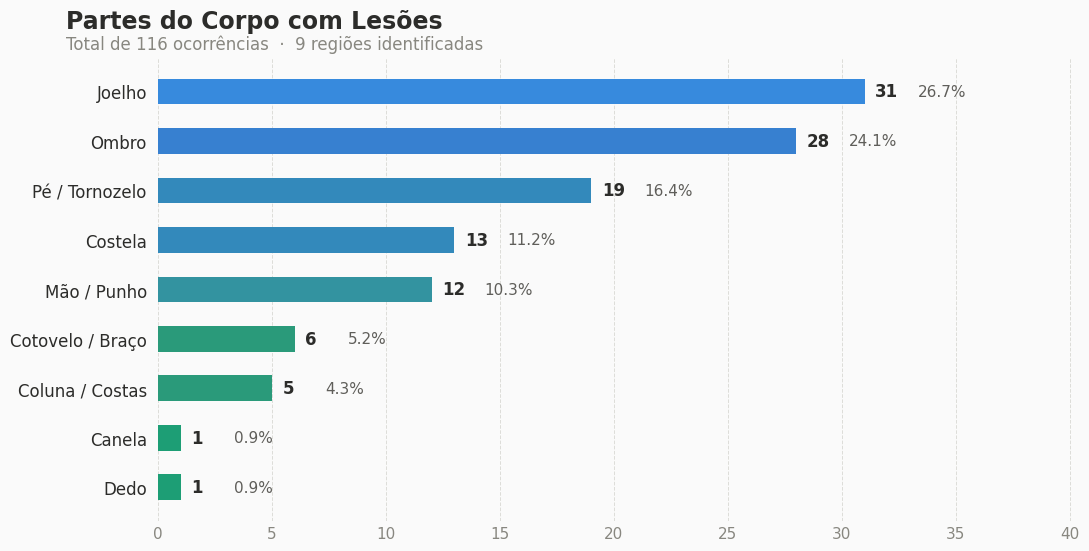

In [ ]:
lugares = (
    df_copia['Se já sofreu lesões, em qual parte do corpo sofreu essa lesão ?']
    .str.strip()
    .str.split(", ")
    .explode()
    .str.strip()
)

lugares_lesionados = lugares.value_counts()

percentual_lugares_lesionados = (
    lugares
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

tabela_lugares_lesionados = pd.DataFrame({
    "Quantidade": lugares_lesionados,
    "Percentual": percentual_lugares_lesionados
})

tabela_lugares_lesionados = tabela_lugares_lesionados.iloc[::-1]

n = len(tabela_lugares_lesionados)
cores_base = ["#1D9E75", "#2A9A7A", "#3393A0", "#3389BB", "#3780D0", "#378ADD"]
cores = [cores_base[int(i * (len(cores_base) - 1) / max(n - 1, 1))] for i in range(n)]

fig, ax = plt.subplots(figsize=(11, max(5, n * 0.62)))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

y = np.arange(n)

barras = ax.barh(
    y,
    tabela_lugares_lesionados["Quantidade"],
    color=cores,
    height=0.52,
    zorder=3,
    linewidth=0,
)

max_val = tabela_lugares_lesionados["Quantidade"].max()
for barra, (idx, row) in zip(barras, tabela_lugares_lesionados.iterrows()):
    w  = barra.get_width()
    cy = barra.get_y() + barra.get_height() / 2

    ax.text(w + max_val * 0.015, cy, str(int(row["Quantidade"])),
            ha="left", va="center",
            fontsize=12, fontweight="bold", color="#2C2C2A")

    ax.text(w + max_val * 0.075, cy, f"{row['Percentual']:.1f}%",
            ha="left", va="center",
            fontsize=11, color="#5F5E5A")

ax.xaxis.grid(True, color="#DDDDD8", linewidth=0.7, linestyle="--", zorder=0)
ax.set_axisbelow(True)

ax.set_yticks(y)
ax.set_yticklabels(
    [i.title() for i in tabela_lugares_lesionados.index],
    fontsize=12, color="#2C2C2A"
)

ax.tick_params(axis="y", length=0, pad=8)
ax.tick_params(axis="x", labelsize=11, colors="#888780", length=0)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

fig.text(0.065, 0.98,
         "Partes do Corpo com Lesões",
         fontsize=17, fontweight="bold", color="#2C2C2A", va="top")
fig.text(0.065, 0.935,
         f"Total de {int(tabela_lugares_lesionados['Quantidade'].sum())} ocorrências  ·  {n} regiões identificadas",
         fontsize=12, color="#888780", va="top")

ax.set_xlim(0, max_val * 1.30)
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("grafico_lugares_lesionados.png", dpi=150, bbox_inches="tight")
plt.show()
#files.download("grafico_lugares_lesionados.png")

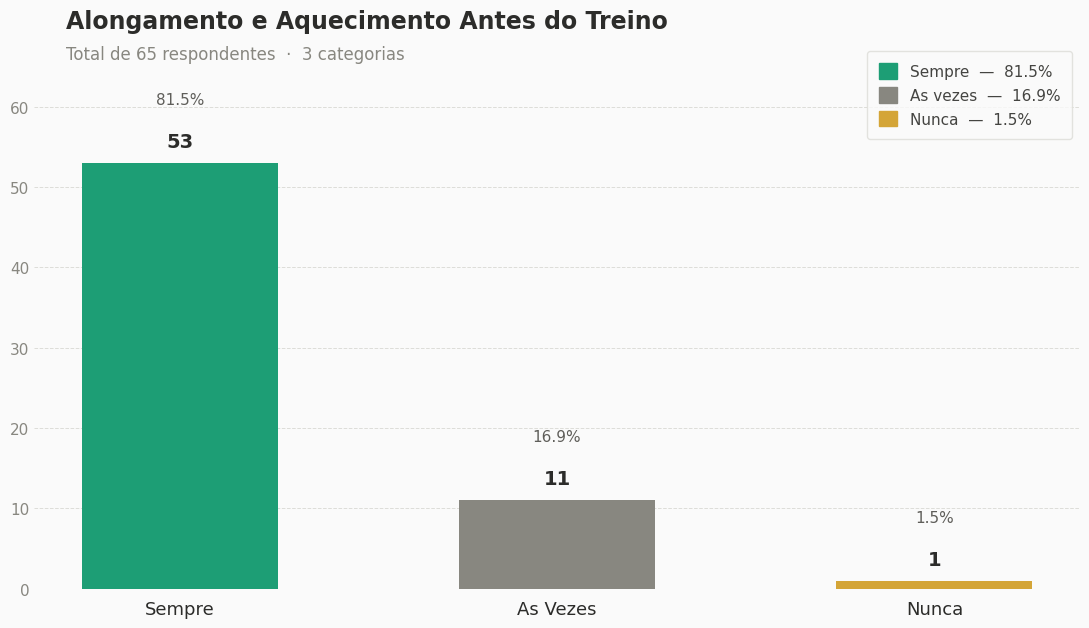

In [ ]:
pratica_alongamento = df_copia["Você faz alongamento e aquecimento antes do treino ? "].value_counts()

porcentagem_pratica_alongamento = (
    df_copia["Você faz alongamento e aquecimento antes do treino ? "]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

tabela_pratica_alongamento = pd.DataFrame({
    "Frequência": pratica_alongamento,
    "Percentual": porcentagem_pratica_alongamento
})

cores_map = {
    "Sempre":    "#1D9E75",   # verde  — hábito positivo
    "Às vezes":  "#378ADD",   # azul   — parcial
    "Nunca":     "#D4A537",   # rosa   — ausência do hábito
}
bar_colors = [cores_map.get(label, "#888780") for label in tabela_pratica_alongamento.index]

fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

x = np.arange(len(tabela_pratica_alongamento))

barras = ax.bar(
    x,
    tabela_pratica_alongamento["Frequência"],
    color=bar_colors,
    width=0.52,
    zorder=3,
    linewidth=0,
)

for barra, (idx, row) in zip(barras, tabela_pratica_alongamento.iterrows()):
    h  = barra.get_height()
    cx = barra.get_x() + barra.get_width() / 2

    ax.text(cx, h + 1.5, str(int(row["Frequência"])),
            ha="center", va="bottom",
            fontsize=14, fontweight="bold", color="#2C2C2A")

    ax.text(cx, h + 7, f"{row['Percentual']:.1f}%",
            ha="center", va="bottom",
            fontsize=11, color="#5F5E5A")

ax.yaxis.grid(True, color="#DDDDD8", linewidth=0.7, linestyle="--", zorder=0)
ax.set_axisbelow(True)

ax.set_xticks(x)
ax.set_xticklabels(
    [i.title() for i in tabela_pratica_alongamento.index],
    fontsize=13, fontweight="500", color="#2C2C2A"
)

ax.tick_params(axis="x", length=0, pad=8)
ax.tick_params(axis="y", labelsize=11, colors="#888780", length=0)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

fig.text(0.065, 0.96,
         "Alongamento e Aquecimento Antes do Treino",
         fontsize=17, fontweight="bold", color="#2C2C2A", va="top")
fig.text(0.065, 0.905,
         f"Total de {int(tabela_pratica_alongamento['Frequência'].sum())} respondentes  ·  {len(tabela_pratica_alongamento)} categorias",
         fontsize=12, color="#888780", va="top")

handles = [
    mpatches.Patch(color=cor, label=f"{idx}  —  {row['Percentual']:.1f}%")
    for (idx, row), cor in zip(tabela_pratica_alongamento.iterrows(), bar_colors)
]
ax.legend(
    handles=handles,
    loc="upper right",
    frameon=True,
    facecolor="#FAFAFA",
    edgecolor="#DDDDD8",
    fontsize=11,
    handlelength=1.2,
    handleheight=1.2,
    labelcolor="#444441",
    labelspacing=0.5,
    borderpad=0.8,
)

ax.set_ylim(0, tabela_pratica_alongamento["Frequência"].max() * 1.28)
ax.set_ylabel("")
ax.set_xlabel("")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("grafico_alongamento.png", dpi=150, bbox_inches="tight")
plt.show()
#files.download("grafico_alongamento.png")

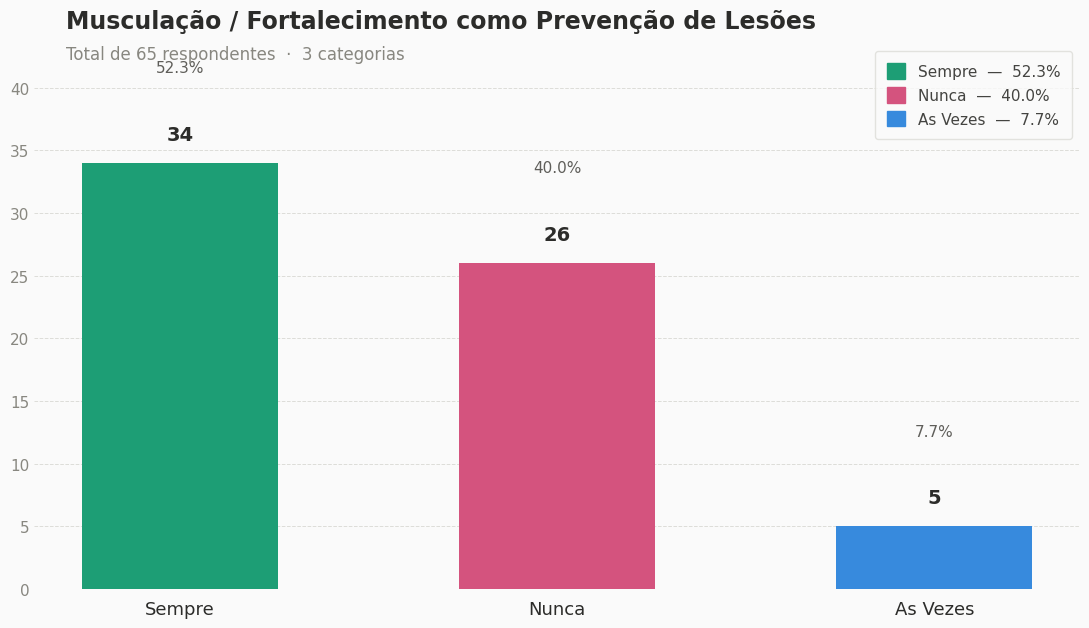

In [ ]:
mapa_respostas = {
    "Faço regularmente": "SEMPRE",
    "Não faço":          "NUNCA",
    "Faço raramento":    "AS VEZES",
}

prevencoes = (
    df_copia['Você prática fortalecimento/musculação como prevenções de lesões ?']
    .replace(mapa_respostas)
    .value_counts()
)

percentual_prevencoes = (
    df_copia['Você prática fortalecimento/musculação como prevenções de lesões ?']
    .replace(mapa_respostas)
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

tabela_prevencoes = pd.DataFrame({
    "Frequência": prevencoes,
    "Percentual": percentual_prevencoes
})

cores_map = {
    "SEMPRE":   "#1D9E75",   # verde  — hábito positivo
    "AS VEZES": "#378ADD",   # azul   — parcial
    "NUNCA":    "#D4537E",   # rosa   — ausência do hábito
}
bar_colors = [cores_map.get(label, "#888780") for label in tabela_prevencoes.index]

fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

x = np.arange(len(tabela_prevencoes))

barras = ax.bar(
    x,
    tabela_prevencoes["Frequência"],
    color=bar_colors,
    width=0.52,
    zorder=3,
    linewidth=0,
)

for barra, (idx, row) in zip(barras, tabela_prevencoes.iterrows()):
    h  = barra.get_height()
    cx = barra.get_x() + barra.get_width() / 2

    ax.text(cx, h + 1.5, str(int(row["Frequência"])),
            ha="center", va="bottom",
            fontsize=14, fontweight="bold", color="#2C2C2A")

    ax.text(cx, h + 7, f"{row['Percentual']:.1f}%",
            ha="center", va="bottom",
            fontsize=11, color="#5F5E5A")

ax.yaxis.grid(True, color="#DDDDD8", linewidth=0.7, linestyle="--", zorder=0)
ax.set_axisbelow(True)

ax.set_xticks(x)
ax.set_xticklabels(
    [i.title() for i in tabela_prevencoes.index],
    fontsize=13, fontweight="500", color="#2C2C2A"
)

ax.tick_params(axis="x", length=0, pad=8)
ax.tick_params(axis="y", labelsize=11, colors="#888780", length=0)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

fig.text(0.065, 0.96,
         "Musculação / Fortalecimento como Prevenção de Lesões",
         fontsize=17, fontweight="bold", color="#2C2C2A", va="top")
fig.text(0.065, 0.905,
         f"Total de {int(tabela_prevencoes['Frequência'].sum())} respondentes  ·  {len(tabela_prevencoes)} categorias",
         fontsize=12, color="#888780", va="top")

handles = [
    mpatches.Patch(color=cor, label=f"{idx.title()}  —  {row['Percentual']:.1f}%")
    for (idx, row), cor in zip(tabela_prevencoes.iterrows(), bar_colors)
]
ax.legend(
    handles=handles,
    loc="upper right",
    frameon=True,
    facecolor="#FAFAFA",
    edgecolor="#DDDDD8",
    fontsize=11,
    handlelength=1.2,
    handleheight=1.2,
    labelcolor="#444441",
    labelspacing=0.5,
    borderpad=0.8,
)

ax.set_ylim(0, tabela_prevencoes["Frequência"].max() * 1.28)
ax.set_ylabel("")
ax.set_xlabel("")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("grafico_prevencao.png", dpi=150, bbox_inches="tight")
plt.show()
#files.download("grafico_prevencao.png")


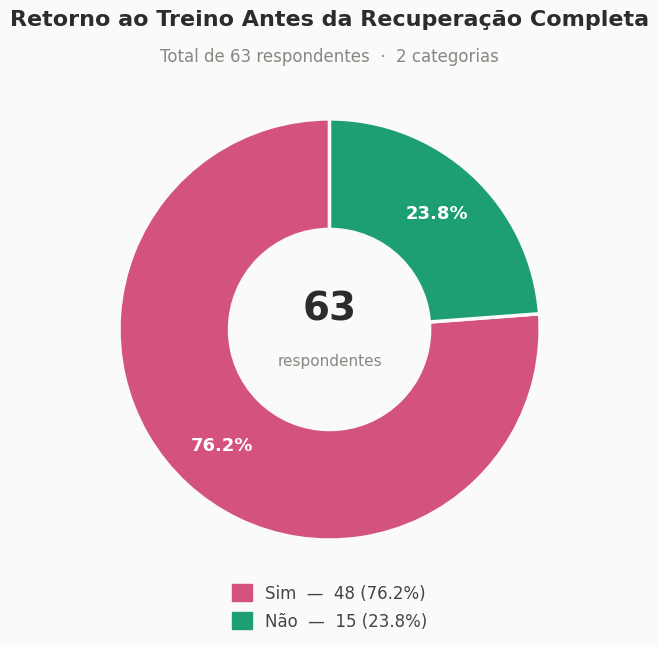

In [ ]:
retorno_antes_da_recuperacao = df_copia['Você voltou a treinar antes de se recuperar 100%?'].value_counts()

percentual_retorno_antes_da_recuperacao = (
    df_copia['Você voltou a treinar antes de se recuperar 100%?']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

tabela_retorno_antes_da_recuperacao = pd.DataFrame({
    "Frequência": retorno_antes_da_recuperacao,
    "Percentual": percentual_retorno_antes_da_recuperacao
})

cores_map = {
    "Sim": "#D4537E",   # rosa — voltou antes de se recuperar (risco)
    "Não": "#1D9E75",   # verde — aguardou a recuperação completa
}
cores = [cores_map.get(label, "#888780") for label in tabela_retorno_antes_da_recuperacao.index]

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

wedges, texts, autotexts = ax.pie(
    tabela_retorno_antes_da_recuperacao["Frequência"],
    labels=None,
    colors=cores,
    autopct="%1.1f%%",
    pctdistance=0.75,
    startangle=90,
    wedgeprops={"linewidth": 2.5,
                "edgecolor": "#FAFAFA",
                "antialiased": True},
)

for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_fontweight("bold")
    autotext.set_color("white")

centro = plt.Circle((0, 0), 0.48, color="#FAFAFA")
ax.add_patch(centro)

total = int(tabela_retorno_antes_da_recuperacao["Frequência"].sum())
ax.text(0, 0.10, str(total),
        ha="center", va="center",
        fontsize=28, fontweight="bold", color="#2C2C2A")
ax.text(0, -0.15, "respondentes",
        ha="center", va="center",
        fontsize=11, color="#888780")

handles = [
    mpatches.Patch(
        color=cor,
        label=f"{label}  —  {int(tabela_retorno_antes_da_recuperacao.loc[label, 'Frequência'])} ({tabela_retorno_antes_da_recuperacao.loc[label, 'Percentual']:.1f}%)"
    )
    for label, cor in zip(tabela_retorno_antes_da_recuperacao.index, cores)
]
ax.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=1,
    frameon=False,
    fontsize=12,
    handlelength=1.2,
    handleheight=1.2,
    labelcolor="#444441",
    labelspacing=0.6,
)

fig.text(0.5, 0.97,
         "Retorno ao Treino Antes da Recuperação Completa",
         ha="center", fontsize=16, fontweight="bold", color="#2C2C2A", va="top")
fig.text(0.5, 0.915,
         f"Total de {total} respondentes  ·  2 categorias",
         ha="center", fontsize=12, color="#888780", va="top")

plt.tight_layout(rect=[0, 0.05, 1, 0.91])
plt.savefig("grafico_pizza_retorno.png", dpi=150, bbox_inches="tight")
plt.show()
#files.download("grafico_pizza_retorno.png")

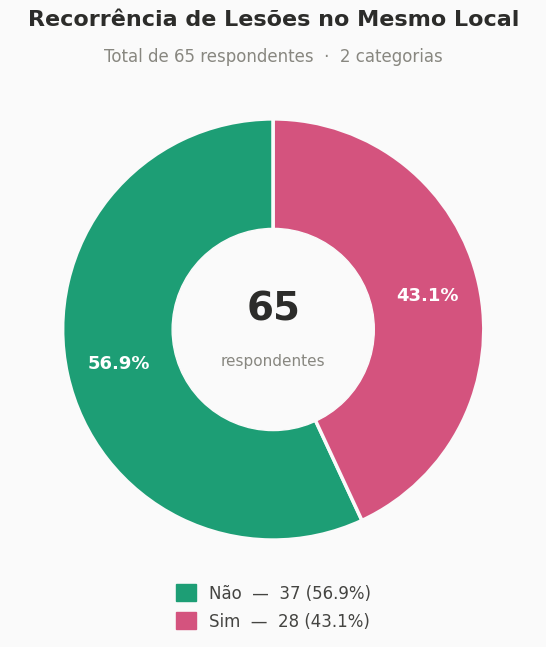

In [ ]:
lesoes_recorrentes = df_copia['Você já teve mais de uma lesão no mesmo local ?'].value_counts()

percentual_lesoes_recorrentes = (
    df_copia['Você já teve mais de uma lesão no mesmo local ?']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

tabela_lesoes_recorrentes = pd.DataFrame({
    "Frequência": lesoes_recorrentes,
    "Percentual": percentual_lesoes_recorrentes
})

cores_map = {
    "Sim": "#D4537E",   # rosa — teve lesão recorrente no mesmo local (alerta)
    "Não": "#1D9E75",   # verde — sem recorrência (positivo)
}
cores = [cores_map.get(label, "#888780") for label in tabela_lesoes_recorrentes.index]

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

wedges, texts, autotexts = ax.pie(
    tabela_lesoes_recorrentes["Frequência"],
    labels=None,
    colors=cores,
    autopct="%1.1f%%",
    pctdistance=0.75,
    startangle=90,
    wedgeprops={"linewidth": 2.5,
                "edgecolor": "#FAFAFA",
                "antialiased": True},
)

for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_fontweight("bold")
    autotext.set_color("white")

centro = plt.Circle((0, 0), 0.48, color="#FAFAFA")
ax.add_patch(centro)

total = int(tabela_lesoes_recorrentes["Frequência"].sum())
ax.text(0, 0.10, str(total),
        ha="center", va="center",
        fontsize=28, fontweight="bold", color="#2C2C2A")
ax.text(0, -0.15, "respondentes",
        ha="center", va="center",
        fontsize=11, color="#888780")

handles = [
    mpatches.Patch(
        color=cor,
        label=f"{label}  —  {int(tabela_lesoes_recorrentes.loc[label, 'Frequência'])} ({tabela_lesoes_recorrentes.loc[label, 'Percentual']:.1f}%)"
    )
    for label, cor in zip(tabela_lesoes_recorrentes.index, cores)
]
ax.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=1,
    frameon=False,
    fontsize=12,
    handlelength=1.2,
    handleheight=1.2,
    labelcolor="#444441",
    labelspacing=0.6,
)

fig.text(0.5, 0.97,
         "Recorrência de Lesões no Mesmo Local",
         ha="center", fontsize=16, fontweight="bold", color="#2C2C2A", va="top")
fig.text(0.5, 0.915,
         f"Total de {total} respondentes  ·  2 categorias",
         ha="center", fontsize=12, color="#888780", va="top")

plt.tight_layout(rect=[0, 0.05, 1, 0.91])
plt.savefig("grafico_pizza_lesoes_recorrentes.png", dpi=150, bbox_inches="tight")
plt.show()
#files.download("grafico_pizza_lesoes_recorrentes.png")

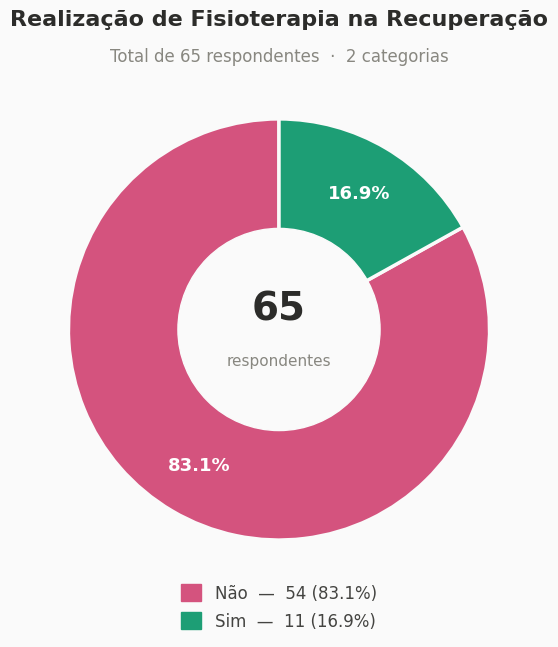

In [ ]:
coluna_normalizada = (
    df_copia['Você fez fisioterapia para recupeação da sua lesaõ ?']
    .str.strip()
    .str.upper()
)

fez_fisioterapia = coluna_normalizada.value_counts()

percentual_fez_fisioterapida = (
    coluna_normalizada
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

tabela_percentual_fez_fisioterapida = pd.DataFrame({
    "Frequência": fez_fisioterapia,
    "Percentual": percentual_fez_fisioterapida
})


cores_map = {
    "SIM": "#1D9E75",   # verde — fez fisioterapia (cuidado com a recuperação)
    "NÃO": "#D4537E",   # rosa  — não fez fisioterapia
    "NAO": "#D4537E",   # fallback caso o dado não tenha acento
    "NÃO ": "#D4537E",  # fallback com espaço residual
}
cores = [cores_map.get(label, "#888780") for label in tabela_percentual_fez_fisioterapida.index]

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

wedges, texts, autotexts = ax.pie(
    tabela_percentual_fez_fisioterapida["Frequência"],
    labels=None,
    colors=cores,
    autopct="%1.1f%%",
    pctdistance=0.75,
    startangle=90,
    wedgeprops={"linewidth": 2.5,
                "edgecolor": "#FAFAFA",
                "antialiased": True},
)

for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_fontweight("bold")
    autotext.set_color("white")

centro = plt.Circle((0, 0), 0.48, color="#FAFAFA")
ax.add_patch(centro)

total = int(tabela_percentual_fez_fisioterapida["Frequência"].sum())
ax.text(0, 0.10, str(total),
        ha="center", va="center",
        fontsize=28, fontweight="bold", color="#2C2C2A")
ax.text(0, -0.15, "respondentes",
        ha="center", va="center",
        fontsize=11, color="#888780")

handles = [
    mpatches.Patch(
        color=cor,
        label=f"{label.title()}  —  {int(tabela_percentual_fez_fisioterapida.loc[label, 'Frequência'])} ({tabela_percentual_fez_fisioterapida.loc[label, 'Percentual']:.1f}%)"
    )
    for label, cor in zip(tabela_percentual_fez_fisioterapida.index, cores)
]
ax.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=1,
    frameon=False,
    fontsize=12,
    handlelength=1.2,
    handleheight=1.2,
    labelcolor="#444441",
    labelspacing=0.6,
)

fig.text(0.5, 0.97,
         "Realização de Fisioterapia na Recuperação",
         ha="center", fontsize=16, fontweight="bold", color="#2C2C2A", va="top")
fig.text(0.5, 0.915,
         f"Total de {total} respondentes  ·  2 categorias",
         ha="center", fontsize=12, color="#888780", va="top")

plt.tight_layout(rect=[0, 0.05, 1, 0.91])
plt.savefig("grafico_pizza_fisioterapia.png", dpi=150, bbox_inches="tight")
plt.show()
#files.download("grafico_pizza_fisioterapia.png")

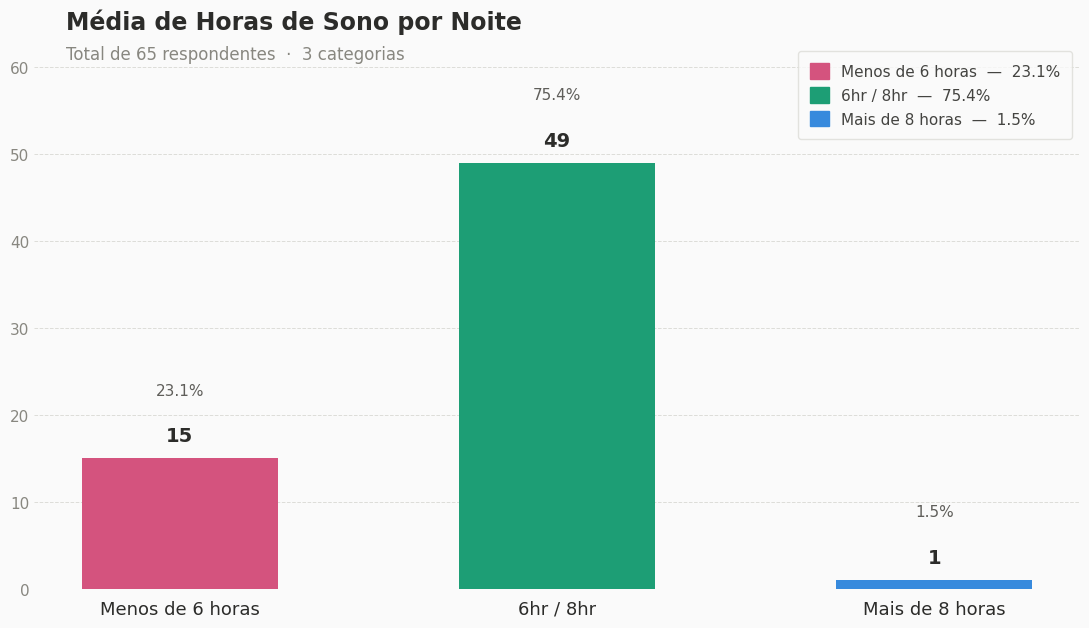

In [ ]:

qtd_sono = df_copia['Quantas horas você dorme em média por noite ?'].value_counts()

percentual_qtd_sono = (
    df_copia['Quantas horas você dorme em média por noite ?']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

tabela_qtd_sono = pd.DataFrame({
    "Frequência": qtd_sono,
    "Percentual": percentual_qtd_sono
})

ordem = ["Menos de 6 horas", "6hr / 8hr", "Mais de 8 horas"]
tabela_qtd_sono = tabela_qtd_sono.reindex(ordem)

cores_map = {
    "Menos de 6 horas": "#D4537E",   # rosa  — sono insuficiente (alerta)
    "6hr / 8hr":        "#1D9E75",   # verde — sono ideal (positivo)
    "Mais de 8 horas":  "#378ADD",   # azul  — sono excessivo (atenção)
}
bar_colors = [cores_map.get(label, "#888780") for label in tabela_qtd_sono.index]

fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

x = np.arange(len(tabela_qtd_sono))

barras = ax.bar(
    x,
    tabela_qtd_sono["Frequência"],
    color=bar_colors,
    width=0.52,
    zorder=3,
    linewidth=0,
)

for barra, (idx, row) in zip(barras, tabela_qtd_sono.iterrows()):
    h  = barra.get_height()
    cx = barra.get_x() + barra.get_width() / 2

    ax.text(cx, h + 1.5, str(int(row["Frequência"])),
            ha="center", va="bottom",
            fontsize=14, fontweight="bold", color="#2C2C2A")

    ax.text(cx, h + 7, f"{row['Percentual']:.1f}%",
            ha="center", va="bottom",
            fontsize=11, color="#5F5E5A")

ax.yaxis.grid(True, color="#DDDDD8", linewidth=0.7, linestyle="--", zorder=0)
ax.set_axisbelow(True)

ax.set_xticks(x)
ax.set_xticklabels(
    tabela_qtd_sono.index,
    fontsize=13, fontweight="500", color="#2C2C2A"
)

ax.tick_params(axis="x", length=0, pad=8)
ax.tick_params(axis="y", labelsize=11, colors="#888780", length=0)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

fig.text(0.065, 0.96,
         "Média de Horas de Sono por Noite",
         fontsize=17, fontweight="bold", color="#2C2C2A", va="top")
fig.text(0.065, 0.905,
         f"Total de {int(tabela_qtd_sono['Frequência'].sum())} respondentes  ·  3 categorias",
         fontsize=12, color="#888780", va="top")

handles = [
    mpatches.Patch(color=cor, label=f"{idx}  —  {row['Percentual']:.1f}%")
    for (idx, row), cor in zip(tabela_qtd_sono.iterrows(), bar_colors)
]
ax.legend(
    handles=handles,
    loc="upper right",
    frameon=True,
    facecolor="#FAFAFA",
    edgecolor="#DDDDD8",
    fontsize=11,
    handlelength=1.2,
    handleheight=1.2,
    labelcolor="#444441",
    labelspacing=0.5,
    borderpad=0.8,
)

ax.set_ylim(0, tabela_qtd_sono["Frequência"].max() * 1.28)
ax.set_ylabel("")
ax.set_xlabel("")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("grafico_sono.png", dpi=150, bbox_inches="tight")
plt.show()
#files.download("grafico_sono.png")

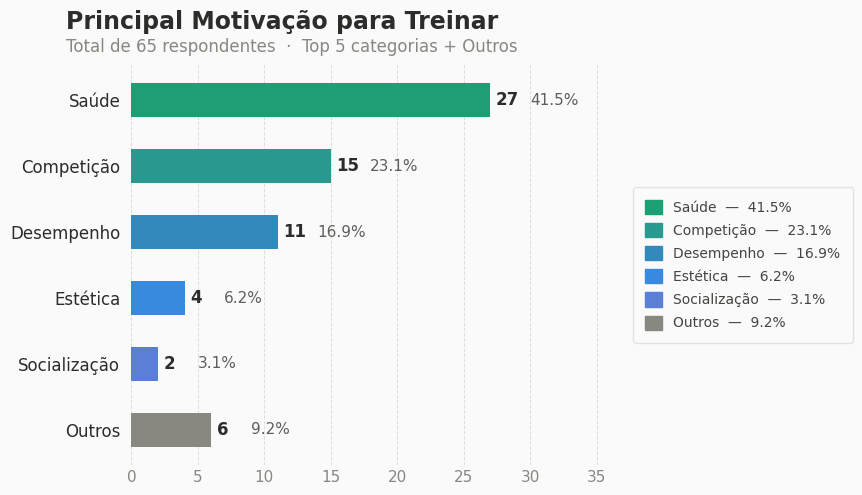

In [ ]:
motivacao = df_copia['Qual sua principal motivação para treinar ?'].value_counts()

principais = motivacao[motivacao > 1]
outros     = motivacao[motivacao <= 1]

outros_total = pd.Series({"Outros": outros.sum()})

motivacao_agrupada = pd.concat([principais, outros_total])

total = motivacao_agrupada.sum()
percentual_motivacao = (motivacao_agrupada / total * 100).round(1)

tabela_motivacao = pd.DataFrame({
    "Frequência": motivacao_agrupada,
    "Percentual": percentual_motivacao
})

tabela_motivacao = tabela_motivacao.iloc[::-1]

cores_map = {
    "Saúde":       "#1D9E75",
    "Competição":  "#2A9A90",
    "Desempenho":  "#3389BB",
    "Estética":    "#378ADD",
    "Socialização":"#5B7FD4",
    "Outros":      "#888780",
}
bar_colors = [cores_map.get(label, "#888780") for label in tabela_motivacao.index]

n = len(tabela_motivacao)
fig, ax = plt.subplots(figsize=(11, max(5, n * 0.75)))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

y = np.arange(n)

barras = ax.barh(
    y,
    tabela_motivacao["Frequência"],
    color=bar_colors,
    height=0.52,
    zorder=3,
    linewidth=0,
)

max_val = tabela_motivacao["Frequência"].max()
for barra, (idx, row) in zip(barras, tabela_motivacao.iterrows()):
    w  = barra.get_width()
    cy = barra.get_y() + barra.get_height() / 2

    ax.text(w + max_val * 0.015, cy, str(int(row["Frequência"])),
            ha="left", va="center",
            fontsize=12, fontweight="bold", color="#2C2C2A")

    ax.text(w + max_val * 0.110, cy, f"{row['Percentual']:.1f}%",
            ha="left", va="center",
            fontsize=11, color="#5F5E5A")

ax.xaxis.grid(True, color="#DDDDD8", linewidth=0.7, linestyle="--", zorder=0)
ax.set_axisbelow(True)

ax.set_yticks(y)
ax.set_yticklabels(tabela_motivacao.index, fontsize=12, color="#2C2C2A")

ax.tick_params(axis="y", length=0, pad=8)
ax.tick_params(axis="x", labelsize=11, colors="#888780", length=0)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

fig.text(0.065, 0.98,
         "Principal Motivação para Treinar",
         fontsize=17, fontweight="bold", color="#2C2C2A", va="top")
fig.text(0.065, 0.925,
         f"Total de {int(total)} respondentes  ·  Top 5 categorias + Outros",
         fontsize=12, color="#888780", va="top")

handles = [
    mpatches.Patch(color=cor, label=f"{idx}  —  {row['Percentual']:.1f}%")
    for (idx, row), cor in zip(tabela_motivacao.iloc[::-1].iterrows(),
                                bar_colors[::-1])
]
ax.legend(
    handles=handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    facecolor="#FAFAFA",
    edgecolor="#DDDDD8",
    fontsize=10,
    handlelength=1.2,
    handleheight=1.2,
    labelcolor="#444441",
    labelspacing=0.6,
    borderpad=0.9,
)

ax.set_xlim(0, max_val * 1.35)
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout(rect=[0, 0, 0.80, 0.90])
plt.savefig("grafico_motivacao.png", dpi=150, bbox_inches="tight")
plt.show()
#files.download("grafico_motivacao.png")

# **CRUZAMENTO DE VARIAVEIS**

─── Tabela de Contingência ───────────────────────────────
Você já sofreu alguma lesão nos últimos 12 meses?  Não  Sim  Total  % Sim  \
Quantas dias você treina por semana?                                        
0 a 2 dias                                           8   10     18   55.6   
3 a 4 dias                                           7   21     28   75.0   
5 dias ou +                                          3   16     19   84.2   
Total                                               18   47     65   72.3   

Você já sofreu alguma lesão nos últimos 12 meses?  % Não  
Quantas dias você treina por semana?                      
0 a 2 dias                                          44.4  
3 a 4 dias                                          25.0  
5 dias ou +                                         15.8  
Total                                               27.7  



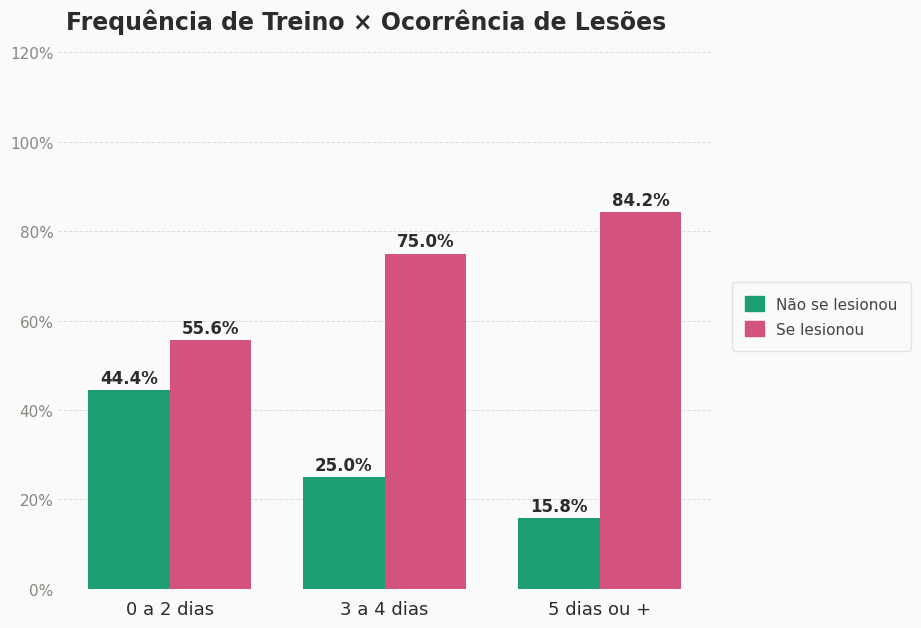

In [ ]:
contingencia = pd.crosstab(
    df_copia["Quantas dias você treina por semana?"],
    df_copia["Você já sofreu alguma lesão nos últimos 12 meses?"],
    margins=True,
    margins_name="Total"
)

contingencia["% Sim"] = (contingencia["Sim"] / contingencia["Total"] * 100).round(1)
contingencia["% Não"] = (contingencia["Não"] / contingencia["Total"] * 100).round(1)

ordem = ["0 a 2 dias", "3 a 4 dias", "5 dias ou +", "Total"]
contingencia = contingencia.reindex(ordem)

print("─── Tabela de Contingência ───────────────────────────────")
print(contingencia)
print()

dados_grafico = contingencia.drop("Total")

cor_sim = "#D4537E"   # rosa — lesionados
cor_nao = "#1D9E75"   # verde — não lesionados

fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

x      = np.arange(len(dados_grafico))
width  = 0.38

barras_nao = ax.bar(x - width/2, dados_grafico["% Não"],
                    width=width, color=cor_nao, zorder=3, linewidth=0)
barras_sim = ax.bar(x + width/2, dados_grafico["% Sim"],
                    width=width, color=cor_sim, zorder=3, linewidth=0)

for barras, col_pct, col_abs in [
    (barras_nao, "% Não", "Não"),
    (barras_sim, "% Sim", "Sim"),
]:
    for barra, (idx, row) in zip(barras, dados_grafico.iterrows()):
        h  = barra.get_height()
        cx = barra.get_x() + barra.get_width() / 2

        ax.text(cx, h + 0.8, f"{row[col_pct]:.1f}%",
                ha="center", va="bottom",
                fontsize=12, fontweight="bold", color="#2C2C2A")


ax.yaxis.grid(True, color="#DDDDD8", linewidth=0.7, linestyle="--", zorder=0)
ax.set_axisbelow(True)

ax.set_xticks(x)
ax.set_xticklabels(dados_grafico.index, fontsize=13, fontweight="500", color="#2C2C2A")

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}%"))
ax.tick_params(axis="x", length=0, pad=8)
ax.tick_params(axis="y", labelsize=11, colors="#888780", length=0)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

fig.text(0.065, 0.96,
         "Frequência de Treino × Ocorrência de Lesões",
         fontsize=17, fontweight="bold", color="#2C2C2A", va="top")


handles = [
    mpatches.Patch(color=cor_nao, label="Não se lesionou"),
    mpatches.Patch(color=cor_sim, label="Se lesionou"),
]
ax.legend(
    handles=handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    facecolor="#FAFAFA",
    edgecolor="#DDDDD8",
    fontsize=11,
    handlelength=1.2,
    handleheight=1.2,
    labelcolor="#444441",
    labelspacing=0.6,
    borderpad=0.9,
)

ax.set_ylim(0, 100 * 1.22)
ax.set_ylabel("")
ax.set_xlabel("")

plt.tight_layout(rect=[0, 0, 0.85, 0.93])
plt.savefig("grafico_cruzamento_treino_lesao.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
from scipy.stats import chi2_contingency

tabela_obs = pd.crosstab(
    df_copia["Quantas dias você treina por semana?"],
    df_copia["Você já sofreu alguma lesão nos últimos 12 meses?"]
).reindex(["0 a 2 dias", "3 a 4 dias", "5 dias ou +"])

chi2, p_valor, graus_liberdade, esperados = chi2_contingency(tabela_obs)

print(f"Qui-Quadrado (χ²): {chi2:.4f}")
print(f"P-valor:           {p_valor:.4f}")
print(f"Graus de liberdade:{graus_liberdade}")
print()

if p_valor < 0.05:
    print("✅ Resultado SIGNIFICATIVO (p < 0.05)")
    print("   Há evidência estatística de associação entre")
    print("   frequência de treino e ocorrência de lesões.")
else:
    print("❌ Resultado NÃO significativo (p >= 0.05)")
    print("   Não há evidência suficiente para afirmar associação.")

Qui-Quadrado (χ²): 3.9684
P-valor:           0.1375
Graus de liberdade:2

❌ Resultado NÃO significativo (p >= 0.05)
   Não há evidência suficiente para afirmar associação.


In [ ]:
from scipy.stats import chi2_contingency, fisher_exact

sparring_map = {
    "Não faço":                    "Não faz",
    "1 a 2 treinos":               "Baixo (1 a 4/mês)",
    "3 a 4 treinos (1 por semana)":"Baixo (1 a 4/mês)",
    "5 a 6 treinos":               "Alto (5+/mês)",
    "+6 treinos de Sparring":      "Alto (5+/mês)",
}

df_copia["Faixa Sparring"] = (
    df_copia['Quantos treinos de Sparring você faz no mês ?']
    .map(sparring_map)
)

tabela_sparring = pd.crosstab(
    df_copia["Faixa Sparring"],
    df_copia["Você já sofreu alguma lesão nos últimos 12 meses?"],
    margins=True,
    margins_name="Total"
)

tabela_sparring["Sim %"] = (tabela_sparring["Sim"] / tabela_sparring["Total"] * 100).round(1)
tabela_sparring["Não %"] = (tabela_sparring["Não"] / tabela_sparring["Total"] * 100).round(1)

ordem = ["Não faz", "Baixo (1 a 4/mês)", "Alto (5+/mês)", "Total"]
tabela_sparring = tabela_sparring.reindex(ordem)

print("─── Tabela de Contingência: Sparring × Lesão ─────────────")
print(tabela_sparring)
print()

tabela_obs = tabela_sparring.drop("Total")[["Sim", "Não"]]
chi2, p_valor, gl, esp = chi2_contingency(tabela_obs)
print(f"Qui-Quadrado (χ²): {chi2:.4f}  |  P-valor: {p_valor:.4f}  |  GL: {gl}")
print()

faixa2_sparring_map = {
    "Não faço":                    "Não faz sparring",
    "1 a 2 treinos":               "Faz sparring",
    "3 a 4 treinos (1 por semana)":"Faz sparring",
    "5 a 6 treinos":               "Faz sparring",
    "+6 treinos de Sparring":      "Faz sparring",
}
df_copia["Faixa Sparring 2"] = (
    df_copia['Quantos treinos de Sparring você faz no mês ?']
    .map(faixa2_sparring_map)
)

tabela_2x2 = pd.crosstab(
    df_copia["Faixa Sparring 2"],
    df_copia["Você já sofreu alguma lesão nos últimos 12 meses?"]
).reindex(["Não faz sparring", "Faz sparring"])

print("─── Tabela 2x2 para Fisher ───────────────────────────────")
print(tabela_2x2)
print()

odds_ratio, p_fisher = fisher_exact(tabela_2x2.values)

print(f"Odds Ratio:     {odds_ratio:.4f}  (invertido: {1/odds_ratio:.2f}x)")
print(f"P-valor Fisher: {p_fisher:.4f}")
print()

if p_fisher < 0.05:
    print("✅ Resultado SIGNIFICATIVO (p < 0.05)")
    print(f"   Quem faz sparring tem {1/odds_ratio:.1f}x mais chance de se lesionar.")
elif p_fisher < 0.10:
    print("⚠️  Resultado LIMÍTROFE (0.05 < p < 0.10)")
    print(f"   Tendência relevante — OR de {1/odds_ratio:.2f}x — amostra insuficiente para confirmar.")
else:
    print("❌ Resultado NÃO significativo (p >= 0.10)")
    print(f"   Sem evidência estatística de associação com n={len(df_copia)}.")

─── Tabela de Contingência: Sparring × Lesão ─────────────
Você já sofreu alguma lesão nos últimos 12 meses?  Não  Sim  Total  Sim %  \
Faixa Sparring                                                              
Não faz                                              1    4      5   80.0   
Baixo (1 a 4/mês)                                   12   21     33   63.6   
Alto (5+/mês)                                        5   22     27   81.5   
Total                                               18   47     65   72.3   

Você já sofreu alguma lesão nos últimos 12 meses?  Não %  
Faixa Sparring                                            
Não faz                                             20.0  
Baixo (1 a 4/mês)                                   36.4  
Alto (5+/mês)                                       18.5  
Total                                               27.7  

Qui-Quadrado (χ²): 2.5218  |  P-valor: 0.2834  |  GL: 2

─── Tabela 2x2 para Fisher ───────────────────────────────
Você já

In [ ]:
tabela_fort = pd.crosstab(
    df_copia["Você prática fortalecimento/musculação como prevenções de lesões ?"],
    df_copia["Você já sofreu alguma lesão nos últimos 12 meses?"],
    margins=True,
    margins_name="Total"
)

tabela_fort["Sim %"] = (tabela_fort["Sim"] / tabela_fort["Total"] * 100).round(1)
tabela_fort["Não %"] = (tabela_fort["Não"] / tabela_fort["Total"] * 100).round(1)

ordem = ["Faço regularmente", "Faço raramento", "Não faço", "Total"]
tabela_fort = tabela_fort.reindex(ordem)

print("─── Tabela de Contingência: Fortalecimento × Lesão ──────────")
print(tabela_fort)
print()

tabela_obs = tabela_fort.drop("Total")[["Sim", "Não"]]
chi2, p_valor, gl, esperados = chi2_contingency(tabela_obs)
print(f"Qui-Quadrado (χ²): {chi2:.4f}  |  P-valor: {p_valor:.4f}  |  GL: {gl}")
print()

df_copia["Faixa Fort"] = df_copia[
    "Você prática fortalecimento/musculação como prevenções de lesões ?"
].map({
    "Faço regularmente": "Faz regularmente",
    "Faço raramento":    "Faz raramente / Não faz",
    "Não faço":          "Faz raramente / Não faz",
})

tabela_2x2 = pd.crosstab(
    df_copia["Faixa Fort"],
    df_copia["Você já sofreu alguma lesão nos últimos 12 meses?"]
).reindex(["Faz regularmente", "Faz raramente / Não faz"])

print("─── Tabela 2x2 para Fisher ───────────────────────────────────")
print(tabela_2x2)
print()

odds_ratio, p_fisher = fisher_exact(tabela_2x2.values)
or_inv = 1 / odds_ratio if odds_ratio != 0 else float("inf")

print(f"Odds Ratio:     {odds_ratio:.4f}  (invertido: {or_inv:.2f}x)")
print(f"P-valor Fisher: {p_fisher:.4f}")
print()

if p_fisher < 0.05:
    print("✅ Resultado SIGNIFICATIVO (p < 0.05)")
elif p_fisher < 0.10:
    print("⚠️  Resultado LIMÍTROFE (0.05 ≤ p < 0.10)")
else:
    print("❌ Resultado NÃO significativo (p ≥ 0.10)")




─── Tabela de Contingência: Fortalecimento × Lesão ──────────
Você já sofreu alguma lesão nos últimos 12 meses?   Não  Sim  Total  Sim %  \
Você prática fortalecimento/musculação como pre...                           
Faço regularmente                                    12   22     34   64.7   
Faço raramento                                        2    3      5   60.0   
Não faço                                              4   22     26   84.6   
Total                                                18   47     65   72.3   

Você já sofreu alguma lesão nos últimos 12 meses?   Não %  
Você prática fortalecimento/musculação como pre...         
Faço regularmente                                    35.3  
Faço raramento                                       40.0  
Não faço                                             15.4  
Total                                                27.7  

Qui-Quadrado (χ²): 3.3264  |  P-valor: 0.1895  |  GL: 2

─── Tabela 2x2 para Fisher ────────────────────────

In [ ]:
from scipy.stats import chi2_contingency, fisher_exact

df_valido = df_copia.dropna(subset=['Há quanto tempo você pratica esse esporte ?',
                                     'Você já sofreu alguma lesão nos últimos 12 meses?'])

print(f"Registros após remover NaN: {len(df_valido)} (removidos: {len(df_copia) - len(df_valido)})")
print()

tabela_tempo = pd.crosstab(
    df_valido['Há quanto tempo você pratica esse esporte ?'],
    df_valido['Você já sofreu alguma lesão nos últimos 12 meses?'],
    margins=True,
    margins_name="Total"
)

tabela_tempo["Sim %"] = (tabela_tempo["Sim"] / tabela_tempo["Total"] * 100).round(1)
tabela_tempo["Não %"] = (tabela_tempo["Não"] / tabela_tempo["Total"] * 100).round(1)

ordem = ["De 0 a 6 meses", "De 6 meses a 1 ano", "De 1 a 2 anos",
         "De 2 a 4 anos", "+4 anos", "Total"]
tabela_tempo = tabela_tempo.reindex(ordem)

print("─── Tabela de Contingência: Tempo de Prática × Lesão ────────")
print(tabela_tempo)
print()

tabela_obs = tabela_tempo.drop("Total")[["Sim", "Não"]]
chi2, p_valor, gl, esperados = chi2_contingency(tabela_obs)
print(f"Qui-Quadrado (χ²): {chi2:.4f}  |  P-valor: {p_valor:.4f}  |  GL: {gl}")
print()

df_valido["Faixa Tempo"] = df_valido['Há quanto tempo você pratica esse esporte ?'].map({
    "De 0 a 6 meses":    "Iniciante (até 1 ano)",
    "De 6 meses a 1 ano":"Iniciante (até 1 ano)",
    "De 1 a 2 anos":     "Experiente (1 ano ou +)",
    "De 2 a 4 anos":     "Experiente (1 ano ou +)",
    "+4 anos":           "Experiente (1 ano ou +)",
})

tabela_2x2 = pd.crosstab(
    df_valido["Faixa Tempo"],
    df_valido["Você já sofreu alguma lesão nos últimos 12 meses?"]
).reindex(["Iniciante (até 1 ano)", "Experiente (1 ano ou +)"])

print("─── Tabela 2x2 para Fisher ───────────────────────────────────")
print(tabela_2x2)
print()

odds_ratio, p_fisher = fisher_exact(tabela_2x2.values)
or_inv = 1 / odds_ratio if odds_ratio != 0 else float("inf")

print(f"Odds Ratio:     {odds_ratio:.4f}  (invertido: {or_inv:.2f}x)")
print(f"P-valor Fisher: {p_fisher:.4f}")
print()

if p_fisher < 0.05:
    print("Resultado SIGNIFICATIVO (p < 0.05)")
    print(f"Experientes têm {or_inv:.1f}x mais chance de lesão que iniciantes.")
elif p_fisher < 0.10:
    print("Resultado LIMITROFE (0.05 <= p < 0.10)")
    print(f"Tendência relevante — OR de {or_inv:.2f}x — amostra insuficiente para confirmar.")
else:
    print("Resultado NAO significativo (p >= 0.10)")
    print(f"Sem evidencia estatistica de associacao com n={len(df_valido)}.")

Registros após remover NaN: 64 (removidos: 1)

─── Tabela de Contingência: Tempo de Prática × Lesão ────────
Você já sofreu alguma lesão nos últimos 12 meses?  Não  Sim  Total  Sim %  \
Há quanto tempo você pratica esse esporte ?                                 
De 0 a 6 meses                                       6    3      9   33.3   
De 6 meses a 1 ano                                   1    5      6   83.3   
De 1 a 2 anos                                        1   11     12   91.7   
De 2 a 4 anos                                        5   12     17   70.6   
+4 anos                                              5   15     20   75.0   
Total                                               18   46     64   71.9   

Você já sofreu alguma lesão nos últimos 12 meses?  Não %  
Há quanto tempo você pratica esse esporte ?               
De 0 a 6 meses                                      66.7  
De 6 meses a 1 ano                                  16.7  
De 1 a 2 anos                         

In [ ]:
from scipy.stats import chi2_contingency
import itertools

df_lesao_modal = df_copia[
    df_copia['Se já sofreu lesões, em qual parte do corpo sofreu essa lesão ?'].notna() &
    df_copia['Qual modalidade pratica ?'].notna()
].copy()

print(f"Registros com ambas as colunas preenchidas: {len(df_lesao_modal)}")
print()

df_lesao_modal["Modalidade"] = (
    df_lesao_modal["Qual modalidade pratica ?"]
    .str.strip().str.split(", ")
)

df_lesao_modal["Regiao"] = (
    df_lesao_modal["Se já sofreu lesões, em qual parte do corpo sofreu essa lesão ?"]
    .str.strip().str.split(", ")
)

registros = []
for _, row in df_lesao_modal.iterrows():
    for mod, reg in itertools.product(row["Modalidade"], row["Regiao"]):
        registros.append({
            "Modalidade": mod.strip(),
            "Regiao":     reg.strip()
        })

df_explodido = pd.DataFrame(registros)

principais_modal = ["Muay Thai", "Jiu Jitsu", "Boxe"]
df_explodido["Modalidade"] = df_explodido["Modalidade"].where(
    df_explodido["Modalidade"].isin(principais_modal), "Outras"
)

contagem_regioes = df_explodido["Regiao"].value_counts()
regioes_principais = contagem_regioes[contagem_regioes >= 3].index
df_explodido["Regiao"] = df_explodido["Regiao"].where(
    df_explodido["Regiao"].isin(regioes_principais), "Outras regiões"
)

print("─── Frequência por modalidade (após explosão) ───────────────")
print(df_explodido["Modalidade"].value_counts())
print()
print("─── Frequência por região (após explosão) ───────────────────")
print(df_explodido["Regiao"].value_counts())
print()

tabela_modal_regiao = pd.crosstab(
    df_explodido["Modalidade"],
    df_explodido["Regiao"],
    margins=True,
    margins_name="Total"
)

print("─── Tabela de Contingência: Modalidade × Região Lesionada ───")
print(tabela_modal_regiao)
print()

tabela_obs = tabela_modal_regiao.drop("Total").drop(columns=["Total"])
chi2, p_valor, gl, esperados = chi2_contingency(tabela_obs)
print(f"Qui-Quadrado (χ²): {chi2:.4f}  |  P-valor: {p_valor:.4f}  |  GL: {gl}")

if p_valor < 0.05:
    print("Resultado SIGNIFICATIVO (p < 0.05)")
    print("Ha associacao entre modalidade praticada e regiao lesionada.")
elif p_valor < 0.10:
    print("Resultado LIMITROFE (0.05 <= p < 0.10)")
else:
    print("Resultado NAO significativo (p >= 0.10)")

Registros com ambas as colunas preenchidas: 59

─── Frequência por modalidade (após explosão) ───────────────
Modalidade
Jiu Jitsu    78
Muay Thai    60
Boxe         48
Outras       19
Name: count, dtype: int64

─── Frequência por região (após explosão) ───────────────────
Regiao
Joelho              57
Ombro               49
Pé / Tornozelo      28
Mão / Punho         22
Costela             20
Cotovelo / Braço    15
Coluna / Costas     12
Outras regiões       2
Name: count, dtype: int64

─── Tabela de Contingência: Modalidade × Região Lesionada ───
Regiao      Coluna / Costas  Costela  Cotovelo / Braço  Joelho  Mão / Punho  \
Modalidade                                                                    
Boxe                      2        5                 3      16            4   
Jiu Jitsu                 3        9                 6      19            8   
Muay Thai                 3        4                 3      19            7   
Outras                    4        2               

In [ ]:
from scipy.stats import chi2_contingency, fisher_exact

df_trip = df_copia[
    df_copia['Quanto tempo demorou para se recuperar ?'].notna()
].copy()

df_trip['Fisioterapia'] = (
    df_trip['Você fez fisioterapia para recupeação da sua lesaõ ?']
    .str.strip().str.capitalize()
)

df_trip['Lesao Recorrente'] = df_trip['Você já teve mais de uma lesão no mesmo local ?']

ordem_tempo = ["1 semana", "2 a 4 semanas", "4 a 6 semanas",
               "6 a 12 semanas", "Mais que 12 semanas"]

df_trip['Tempo Recuperacao'] = pd.Categorical(
    df_trip['Quanto tempo demorou para se recuperar ?'],
    categories=ordem_tempo,
    ordered=True
)

print(f"Registros válidos: {len(df_trip)}")
print()
print("Fisioterapia normalizada:", df_trip['Fisioterapia'].value_counts().to_dict())
print("Lesão recorrente:",         df_trip['Lesao Recorrente'].value_counts().to_dict())
print()

tab1 = pd.crosstab(
    df_trip['Tempo Recuperacao'],
    df_trip['Fisioterapia'],
    margins=True, margins_name="Total"
)
tab1["Fez Fisio %"] = (tab1.get("Sim", 0) / tab1["Total"] * 100).round(1)

print("─── Tempo de Recuperação × Fisioterapia ─────────────────────")
print(tab1)
print()

chi2_1, p1, gl1, _ = chi2_contingency(
    tab1.drop("Total").drop(columns="Total").fillna(0)
)
print(f"Qui-Quadrado: χ²={chi2_1:.4f}  |  P-valor: {p1:.4f}  |  GL: {gl1}")
print()

tab2 = pd.crosstab(
    df_trip['Tempo Recuperacao'],
    df_trip['Lesao Recorrente'],
    margins=True, margins_name="Total"
)
tab2["Recorrente %"] = (tab2.get("Sim", 0) / tab2["Total"] * 100).round(1)

print("─── Tempo de Recuperação × Lesão Recorrente ─────────────────")
print(tab2)
print()

chi2_2, p2, gl2, _ = chi2_contingency(
    tab2.drop("Total").drop(columns="Total").fillna(0)
)
print(f"Qui-Quadrado: χ²={chi2_2:.4f}  |  P-valor: {p2:.4f}  |  GL: {gl2}")
print()

tab3 = pd.crosstab(
    df_trip['Fisioterapia'],
    df_trip['Lesao Recorrente'],
).reindex(["Sim", "Não"])

tab3["Recorrente %"] = (tab3.get("Sim", 0) / tab3.sum(axis=1) * 100).round(1)

print("─── Fisioterapia × Lesão Recorrente ─────────────────────────")
print(tab3)
print()

odds_ratio, p_fisher = fisher_exact(tab3[["Não", "Sim"]].values)
or_inv = 1 / odds_ratio if odds_ratio > 0 else float("inf")
print(f"Odds Ratio: {odds_ratio:.4f}  (invertido: {or_inv:.2f}x)")
print(f"P-valor Fisher: {p_fisher:.4f}")
print()

print("═══ RESUMO ══════════════════════════════════════════════════")
for nome, chi2_v, p_v, gl_v in [
    ("Tempo Recup. × Fisioterapia",    chi2_1, p1, gl1),
    ("Tempo Recup. × Lesao Recorrente",chi2_2, p2, gl2),
]:
    status = "SIGNIFICATIVO" if p_v < 0.05 else ("LIMITROFE" if p_v < 0.10 else "nao signif.")
    print(f"{nome:<40} χ²={chi2_v:.2f}  p={p_v:.4f}  GL={gl_v}  [{status}]")

status_f = "SIGNIFICATIVO" if p_fisher < 0.05 else ("LIMITROFE" if p_fisher < 0.10 else "nao signif.")
print(f"{'Fisioterapia × Lesao Recorrente':<40} OR={odds_ratio:.2f}  p={p_fisher:.4f}            [{status_f}]")

Registros válidos: 63

Fisioterapia normalizada: {'Não': 52, 'Sim': 11}
Lesão recorrente: {'Não': 35, 'Sim': 28}

─── Tempo de Recuperação × Fisioterapia ─────────────────────
Fisioterapia         Não  Sim  Total  Fez Fisio %
Tempo Recuperacao                                
1 semana               6    1      7         14.3
2 a 4 semanas         26    3     29         10.3
4 a 6 semanas          5    3      8         37.5
6 a 12 semanas         7    2      9         22.2
Mais que 12 semanas    8    2     10         20.0
Total                 52   11     63         17.5

Qui-Quadrado: χ²=34.3750  |  P-valor: 0.0000  |  GL: 8

─── Tempo de Recuperação × Lesão Recorrente ─────────────────
Lesao Recorrente     Não  Sim  Total  Recorrente %
Tempo Recuperacao                                 
1 semana               6    1      7          14.3
2 a 4 semanas         18   11     29          37.9
4 a 6 semanas          5    3      8          37.5
6 a 12 semanas         4    5      9          55.6

In [ ]:

df_valid = df_copia.dropna(subset=[
    "Quantas dias você treina por semana?",
    "Você prática fortalecimento/musculação como prevenções de lesões ?",
    "Você já sofreu alguma lesão nos últimos 12 meses?"
]).copy()

print(f"Registros válidos: {len(df_valid)}")
print()

df_valid["Fortalecimento"] = df_valid[
    "Você prática fortalecimento/musculação como prevenções de lesões ?"
]

df_valid["Fort 2 grupos"] = df_valid["Fortalecimento"].map({
    "Faço regularmente": "Faz fortalecimento",
    "Faço raramento":    "Nao faz / raramente",
    "Não faço":          "Nao faz / raramente",
})

ordem_treino = ["0 a 2 dias", "3 a 4 dias", "5 dias ou +"]
ordem_fort   = ["Faço regularmente", "Faço raramente", "Não faço"]

print("═" * 65)
resultados = {}   # guarda os dados para o gráfico

for grupo in ordem_fort:
    df_grupo = df_valid[df_valid["Fortalecimento"] == grupo]

    tab = pd.crosstab(
        pd.Categorical(df_grupo["Quantas dias você treina por semana?"],
                       categories=ordem_treino, ordered=True),
        df_grupo["Você já sofreu alguma lesão nos últimos 12 meses?"],
        margins=True, margins_name="Total"
    )

    for col in ["Sim", "Não"]:
        if col not in tab.columns:
            tab[col] = 0

    tab["Sim %"] = (tab["Sim"] / tab["Total"] * 100).round(1)
    tab["Não %"] = (tab["Não"] / tab["Total"] * 100).round(1)

    print(f"\n─── {grupo} ───────────────────────────────────────────")
    print(tab)

    tabela_obs = tab.drop("Total")[["Sim", "Não"]].fillna(0)
    try:
        chi2, p_val, gl, _ = chi2_contingency(tabela_obs)
        status = "SIGNIFICATIVO" if p_val < 0.05 else ("LIMITROFE" if p_val < 0.10 else "nao signif.")
        print(f"Qui-Quadrado: χ²={chi2:.4f}  P-valor={p_val:.4f}  GL={gl}  [{status}]")
    except Exception as e:
        chi2, p_val, gl = 0, 1, 0
        print(f"Qui-Quadrado: nao calculavel ({e})")

    resultados[grupo] = {
        "tab": tab,
        "chi2": chi2, "p_val": p_val
    }

print()

print("═" * 65)
print("─── Fisher Exact por faixa de treino (Faz vs Nao faz) ───────")
for faixa in ordem_treino:
    df_faixa = df_valid[df_valid["Quantas dias você treina por semana?"] == faixa]
    tab_f = pd.crosstab(
        df_faixa["Fort 2 grupos"],
        df_faixa["Você já sofreu alguma lesão nos últimos 12 meses?"]
    ).reindex(["Faz fortalecimento", "Nao faz / raramente"]).fillna(0)

    for col in ["Sim", "Não"]:
        if col not in tab_f.columns:
            tab_f[col] = 0

    try:
        or_val, p_f = fisher_exact(tab_f[["Não", "Sim"]].values)
        or_inv = 1/or_val if or_val > 0 else float("inf")
        status = "SIGNIFICATIVO" if p_f < 0.05 else ("LIMITROFE" if p_f < 0.10 else "nao signif.")
        print(f"{faixa:<15}  OR={or_val:.2f} (inv={or_inv:.2f}x)  p={p_f:.4f}  [{status}]")
    except Exception as e:
        print(f"{faixa:<15}  nao calculavel ({e})")



Registros válidos: 65

═════════════════════════════════════════════════════════════════

─── Faço regularmente ───────────────────────────────────────────
Você já sofreu alguma lesão nos últimos 12 meses?  Não  Sim  Total  Sim %  \
row_0                                                                       
0 a 2 dias                                           6    5     11   45.5   
3 a 4 dias                                           4    8     12   66.7   
5 dias ou +                                          2    9     11   81.8   
Total                                               12   22     34   64.7   

Você já sofreu alguma lesão nos últimos 12 meses?  Não %  
row_0                                                     
0 a 2 dias                                          54.5  
3 a 4 dias                                          33.3  
5 dias ou +                                         18.2  
Total                                               35.3  
Qui-Quadrado: χ²=3.2158  P-

KeyError: 'Total'

In [ ]:
from scipy.stats import fisher_exact

df_retorno = df_copia.dropna(subset=[
    'Você voltou a treinar antes de se recuperar 100%?',
    'Você já teve mais de uma lesão no mesmo local ?'
]).copy()

print(f"Registros válidos: {len(df_retorno)} (removidos: {len(df_copia) - len(df_retorno)})")
print()

tabela = pd.crosstab(
    df_retorno['Você voltou a treinar antes de se recuperar 100%?'],
    df_retorno['Você já teve mais de uma lesão no mesmo local ?'],
    margins=True,
    margins_name="Total"
)

tabela["Recorrente %"] = (tabela["Sim"] / tabela["Total"] * 100).round(1)

tabela = tabela.reindex(["Sim", "Não", "Total"])

print("─── Retorno Precoce × Lesão Recorrente ──────────────────────")
print(tabela)
print()

tabela_2x2 = tabela.drop("Total")[["Não", "Sim"]]
odds_ratio, p_fisher = fisher_exact(tabela_2x2.values)
or_inv = 1 / odds_ratio if odds_ratio > 0 else float("inf")

print(f"Odds Ratio:     {odds_ratio:.4f}  (invertido: {or_inv:.2f}x)")
print(f"P-valor Fisher: {p_fisher:.4f}")
print()

if p_fisher < 0.05:
    print("SIGNIFICATIVO (p < 0.05)")
    print(f"Quem voltou antes tem {or_inv:.1f}x mais chance de lesao recorrente.")
elif p_fisher < 0.10:
    print("LIMITROFE (0.05 <= p < 0.10)")
else:
    print("NAO significativo (p >= 0.10)")

Registros válidos: 63 (removidos: 2)

─── Retorno Precoce × Lesão Recorrente ──────────────────────
Você já teve mais de uma lesão no mesmo local ?    Não  Sim  Total  \
Você voltou a treinar antes de se recuperar 100%?                    
Sim                                                 23   25     48   
Não                                                 12    3     15   
Total                                               35   28     63   

Você já teve mais de uma lesão no mesmo local ?    Recorrente %  
Você voltou a treinar antes de se recuperar 100%?                
Sim                                                        52.1  
Não                                                        20.0  
Total                                                      44.4  

Odds Ratio:     0.2300  (invertido: 4.35x)
P-valor Fisher: 0.0385

SIGNIFICATIVO (p < 0.05)
Quem voltou antes tem 4.3x mais chance de lesao recorrente.
